In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/duypham/NCKH/Retinal-vessels-segmentation/')
from utils import *


In [68]:
cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/DRIVE/test/images/01_test.tif').shape

(584, 565, 3)

In [ ]:
import torch
import kornia

def extract_patches_with_target_count(img, patch_size, target_patches_per_dim):
    if isinstance(patch_size, int):
        ph, pw = patch_size, patch_size
    else:
        ph, pw = patch_size

    _, _, H, W = img.shape
    sh = (H - ph) // (target_patches_per_dim[0] - 1) if target_patches_per_dim[0] > 1 else H
    sw = (W - pw) // (target_patches_per_dim[1] - 1) if target_patches_per_dim[1] > 1 else W

    patches = kornia.contrib.extract_tensor_patches(img, (ph, pw), stride=(sh, sw),allow_auto_padding=True)
    return patches, (sh, sw)
def reverse_to_original_image(patches, original_size,patch_size,stride):
    original_image = kornia.contrib.combine_tensor_patches(patches, original_size=original_size,window_size=patch_size,stride=stride,allow_auto_unpadding=True)
    return original_image

img = transforms.ToTensor()(cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/mask/Image_11L_1stHO.png',0)).unsqueeze(0) # 1 ảnh RGB 256x256
patches, stride = extract_patches_with_target_count(img, patch_size=64, target_patches_per_dim=(21, 22))
print(patches.shape)  # [B, N, C, ph, pw]
print("Stride:", stride)


ValueError: Invalid input shape, we expect BxCxHxW. Got: torch.Size([1, 960, 999])

In [65]:
extract_patches_with_target_count(torch.rand(1,3,584,564), patch_size=64, target_patches_per_dim=(21, 22))[0].shape

torch.Size([1, 483, 3, 64, 64])

In [ ]:
fig,ax=plt.subplots(22,23,figsize=(7,7))
for i,p in enumerate(patches.squeeze()):
    ax[i//23,i%23].imshow(p)
    ax[i//23,i%23].axis(False)
plt.show()

In [56]:
img = transforms.ToTensor()(cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/images/Image_11L.jpg',0)).unsqueeze(0) # 1 ảnh RGB 256x256
patches_img, stride = extract_patches_with_target_count(img, patch_size=64, target_patches_per_dim=(21, 22))

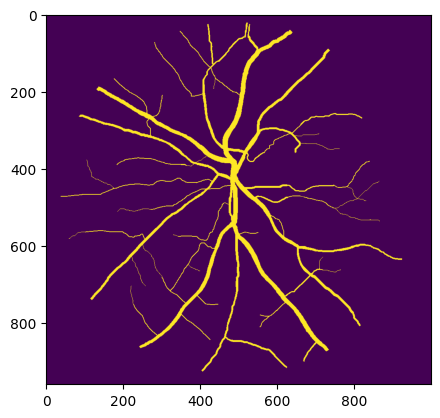

In [60]:
plt.imshow(cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/mask/Image_11L_1stHO.png',0))

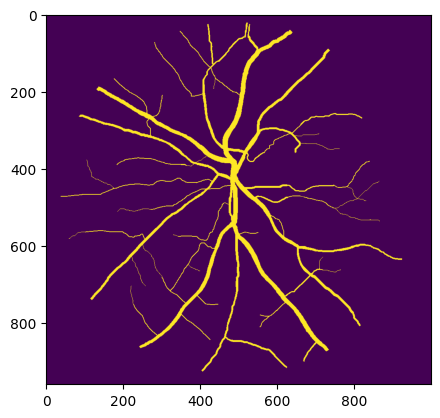

In [59]:
plt.imshow(reverse_to_original_image(patches, (960,999),64,(44,44)).squeeze())

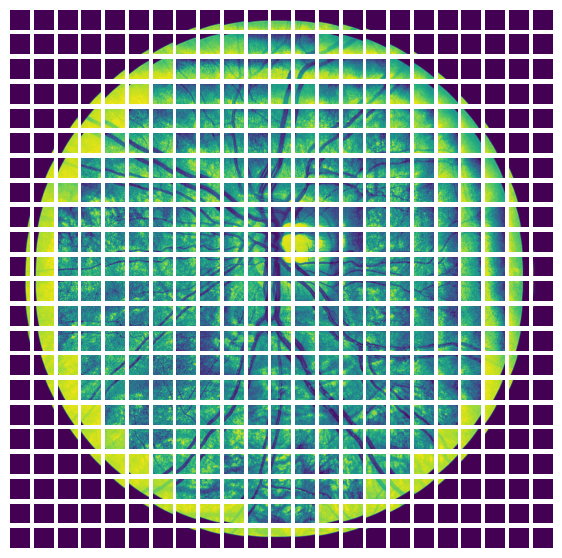

In [57]:
fig,ax=plt.subplots(22,23,figsize=(7,7))
for i,p in enumerate(patches_img.squeeze()):
    ax[i//23,i%23].imshow(p)
    ax[i//23,i%23].axis(False)
plt.show()

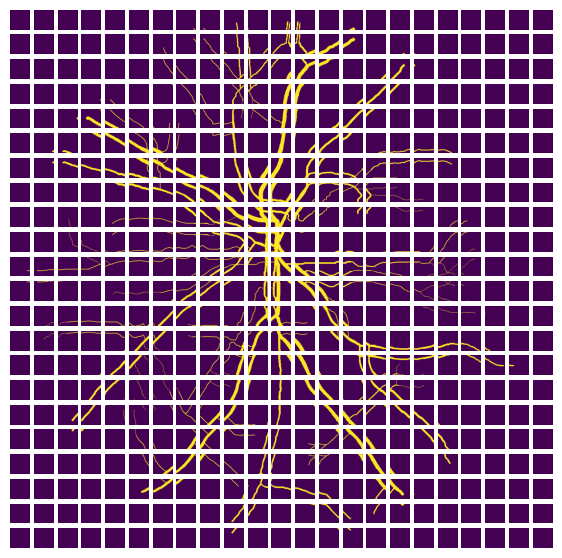

In [55]:
fig,ax=plt.subplots(22,23,figsize=(7,7))
for i,p in enumerate(patches.squeeze()):
    ax[i//23,i%23].imshow(p)
    ax[i//23,i%23].axis(False)
plt.show()

In [ ]:
ax

In [48]:
22*23

506

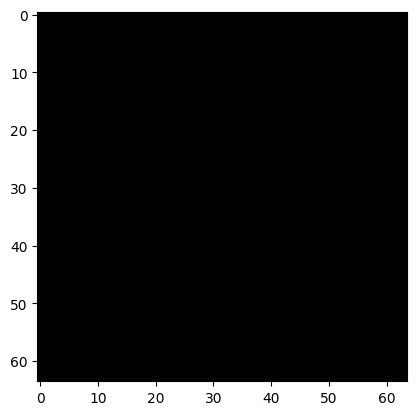

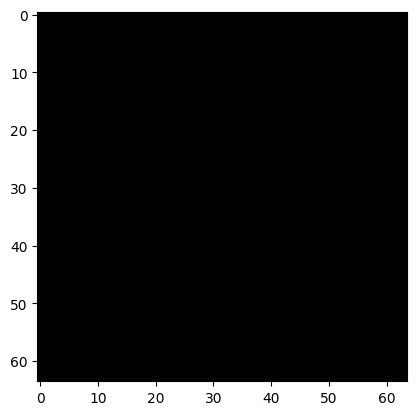

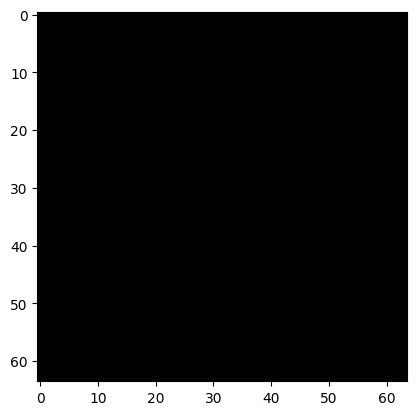

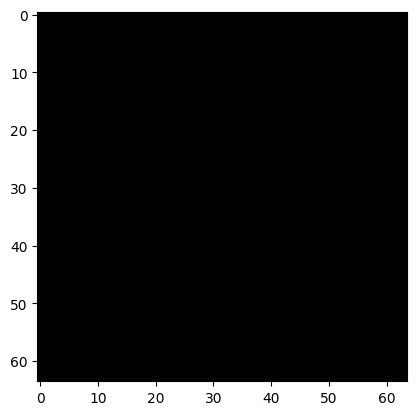

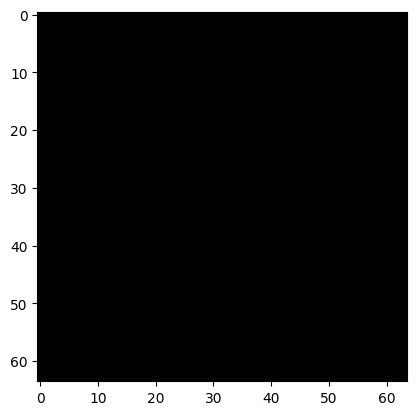

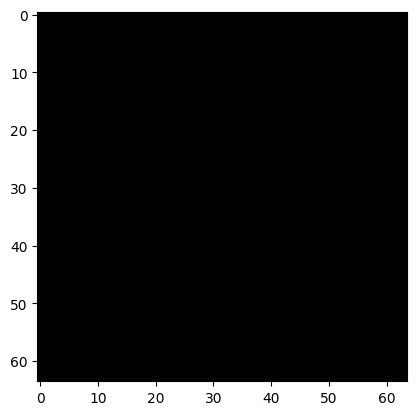

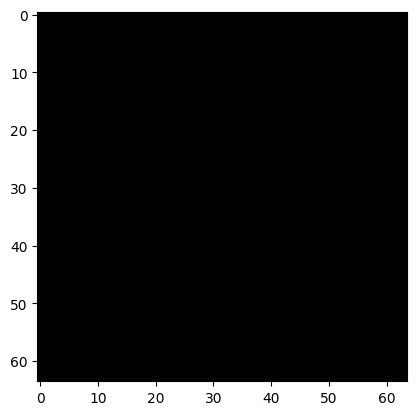

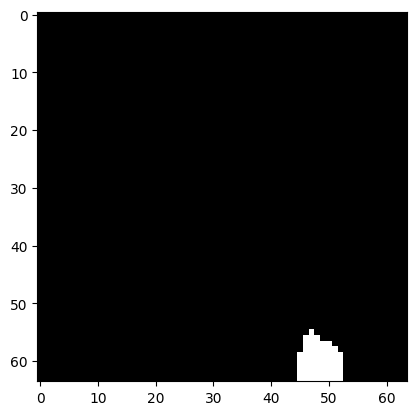

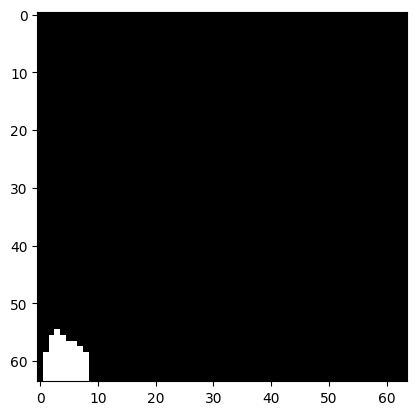

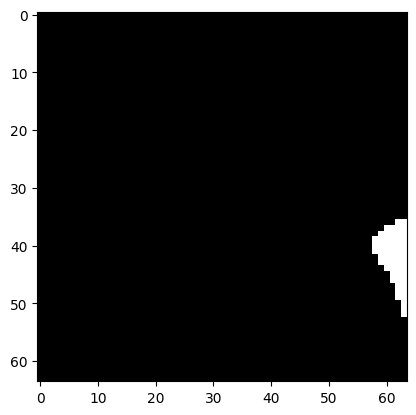

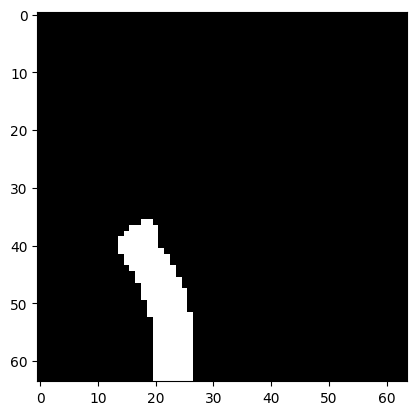

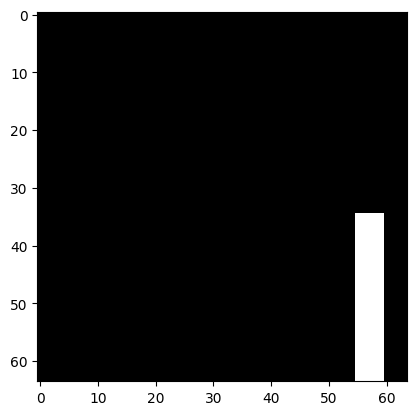

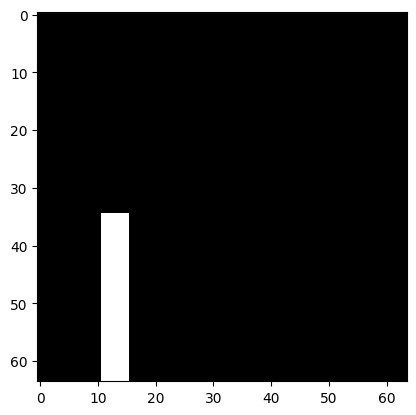

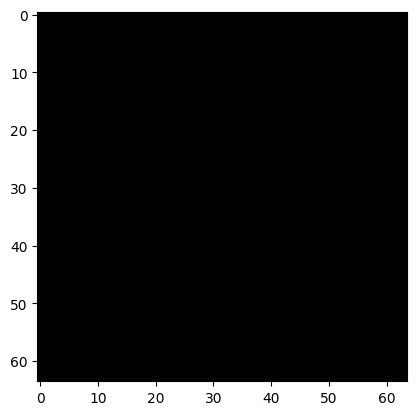

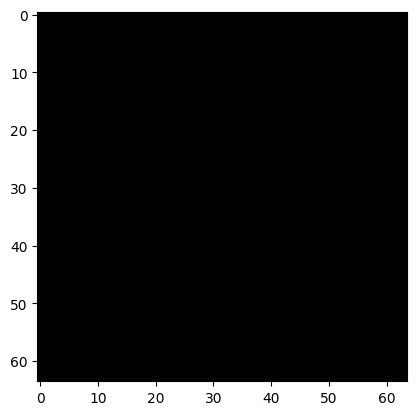

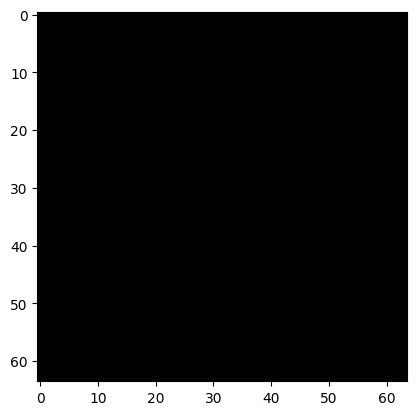

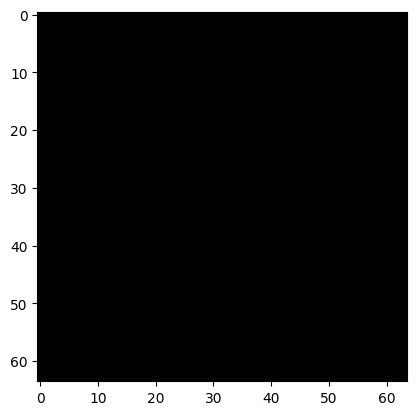

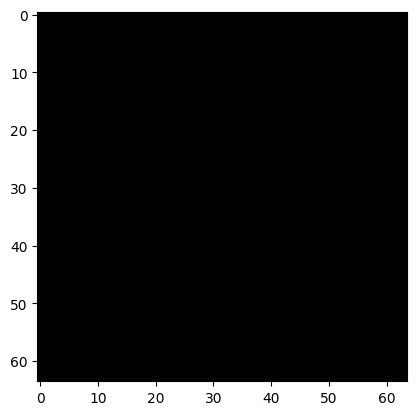

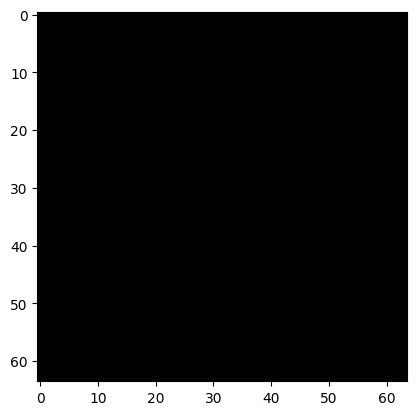

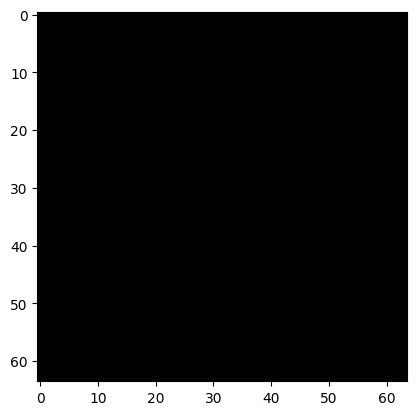

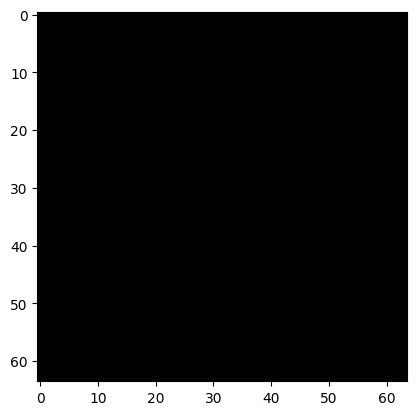

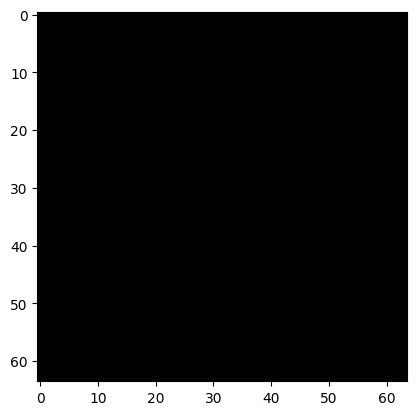

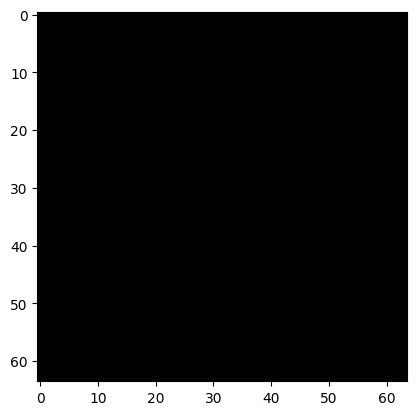

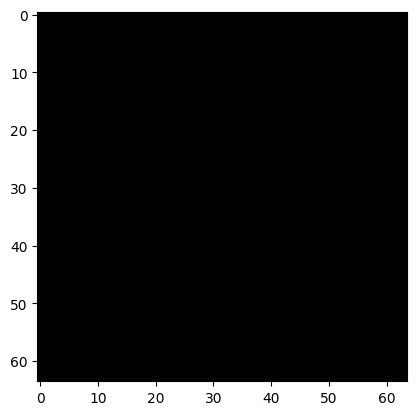

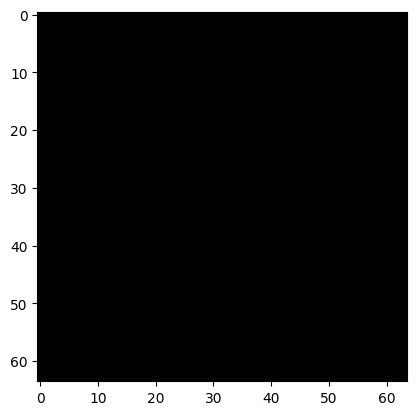

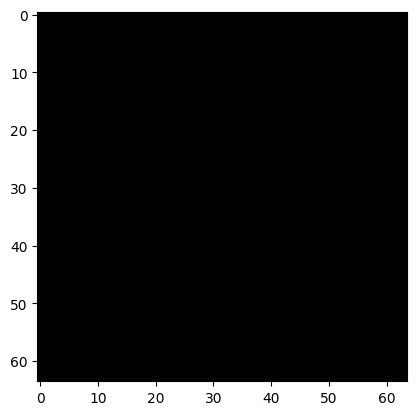

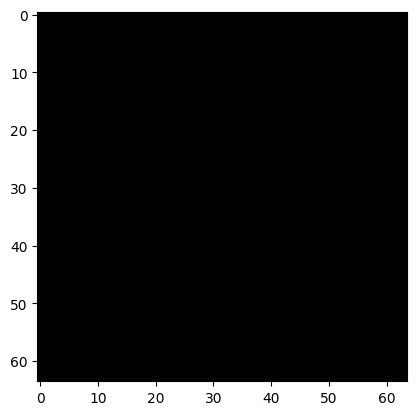

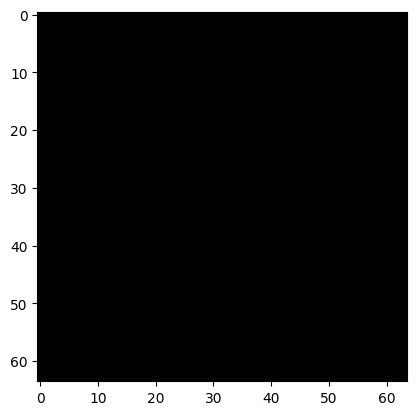

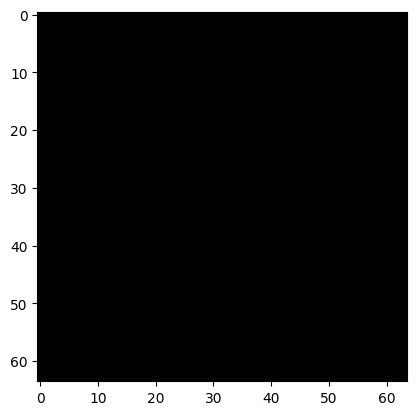

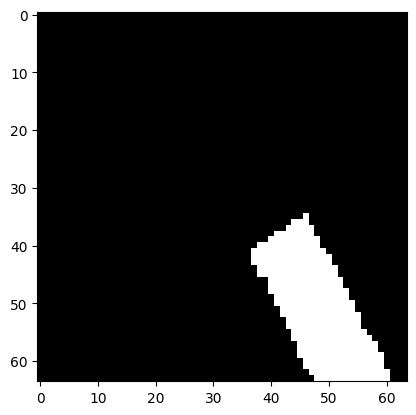

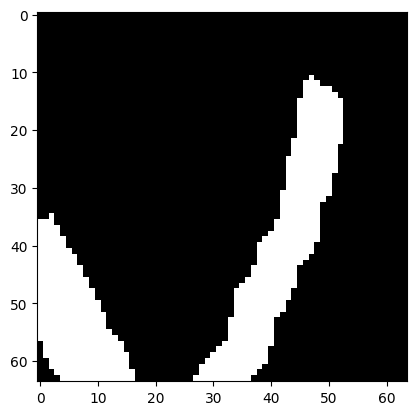

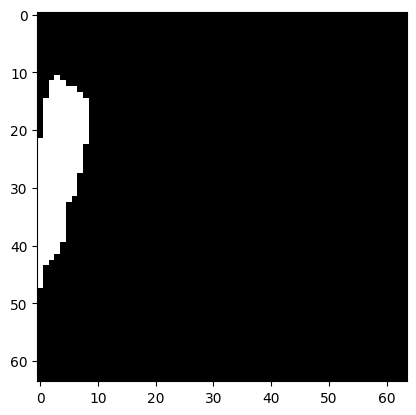

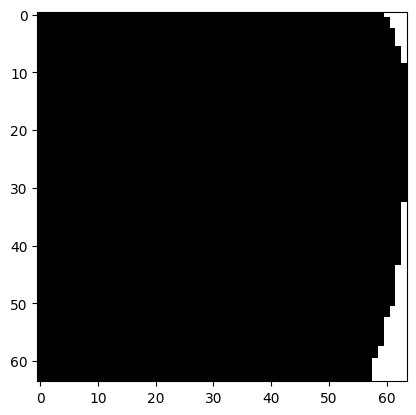

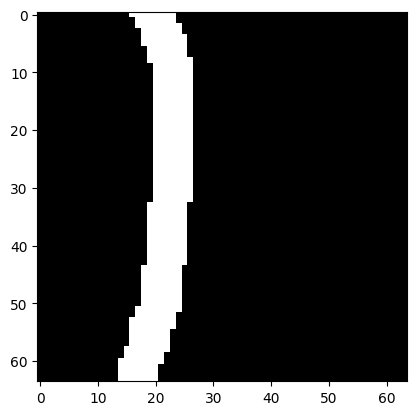

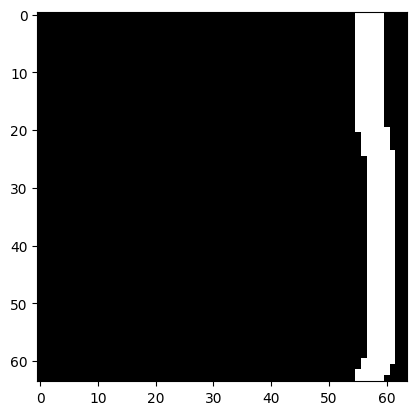

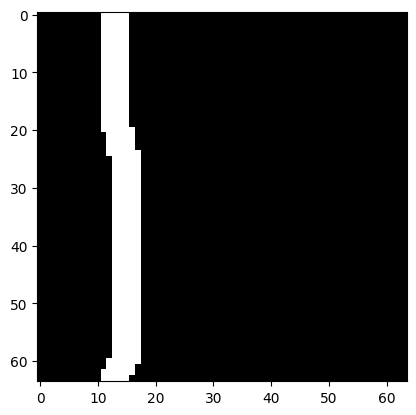

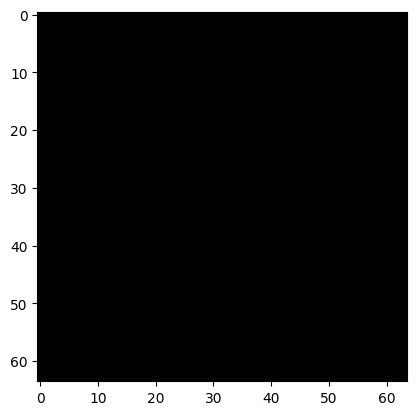

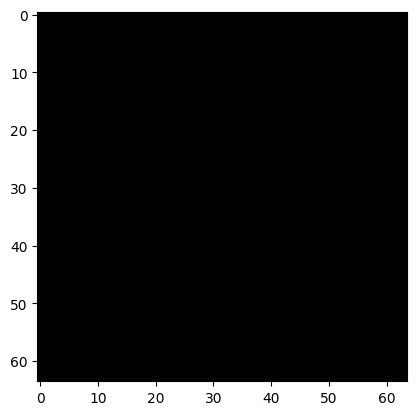

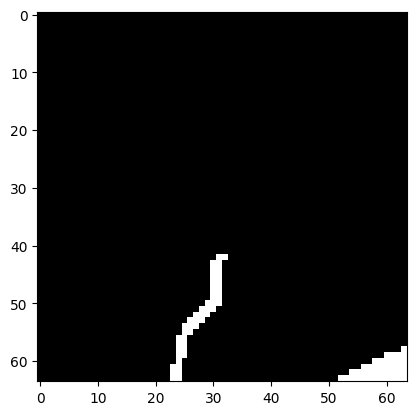

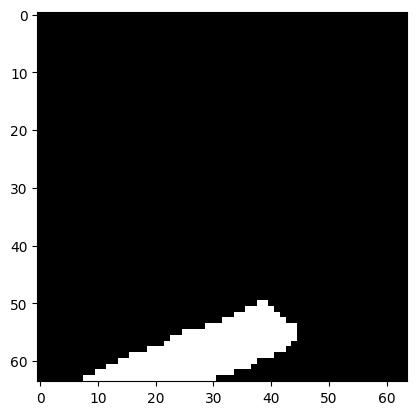

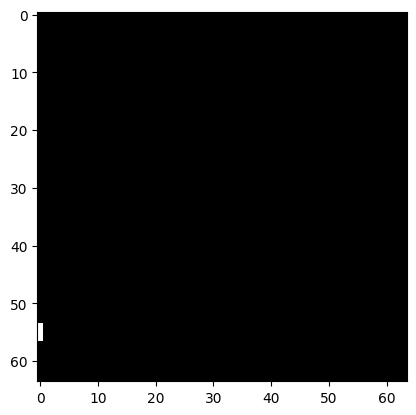

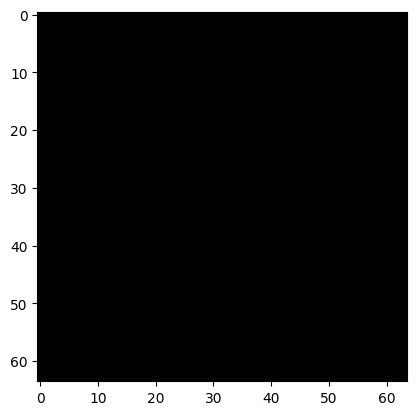

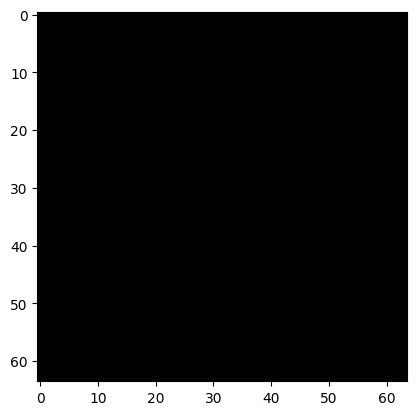

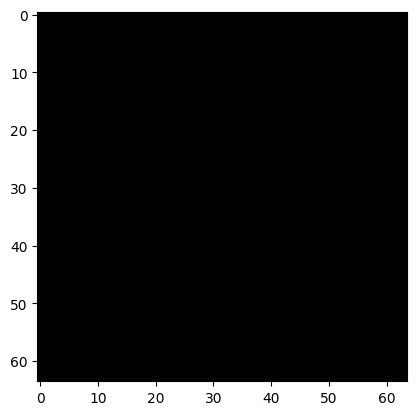

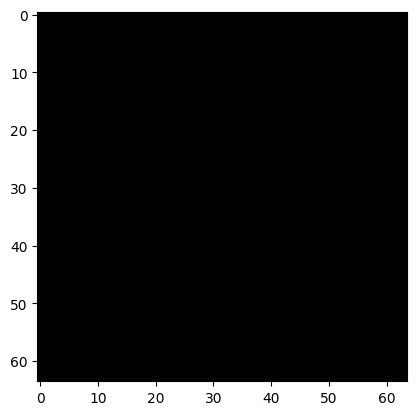

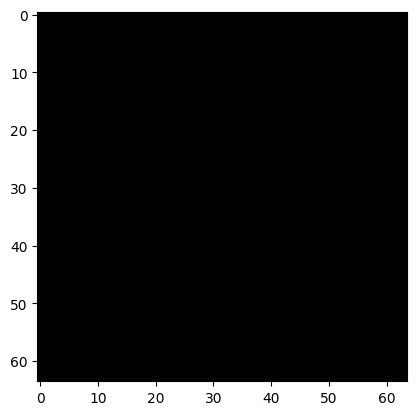

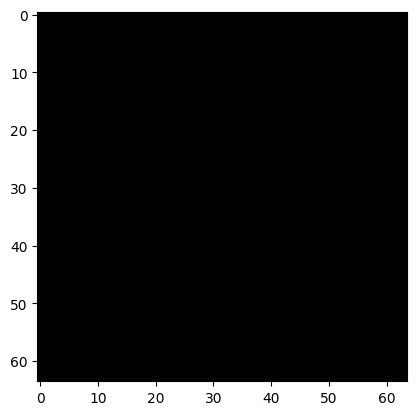

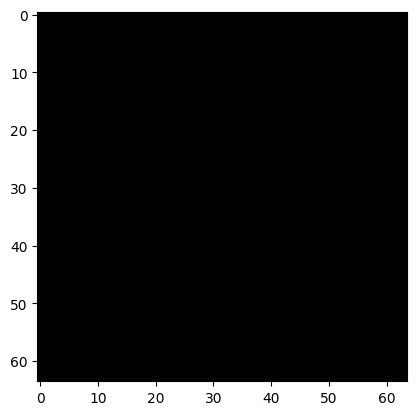

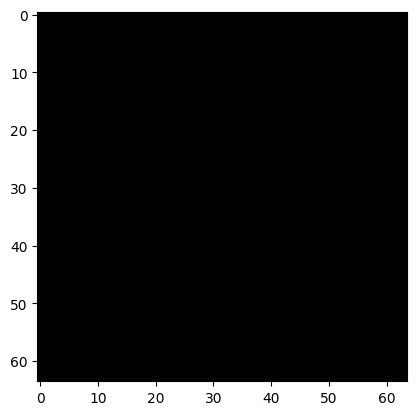

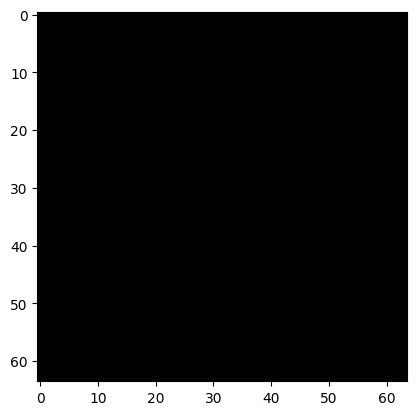

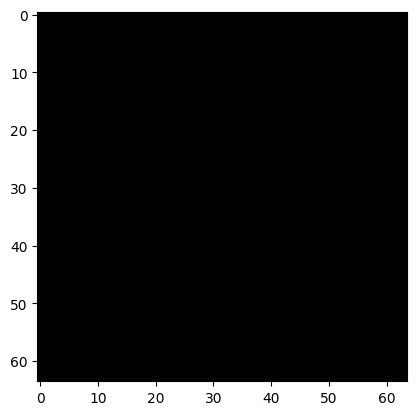

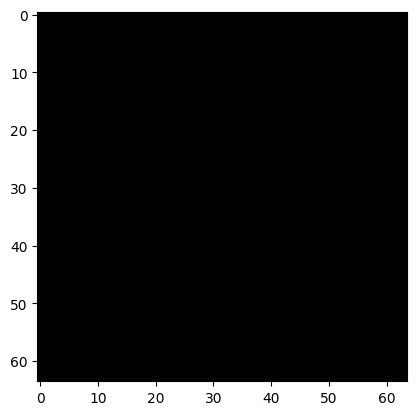

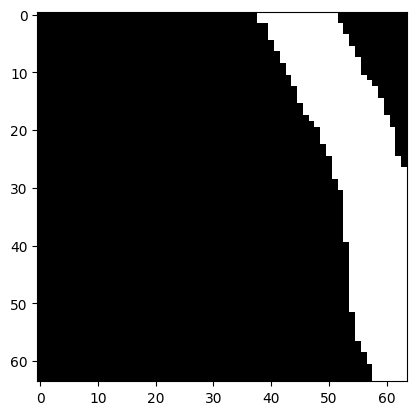

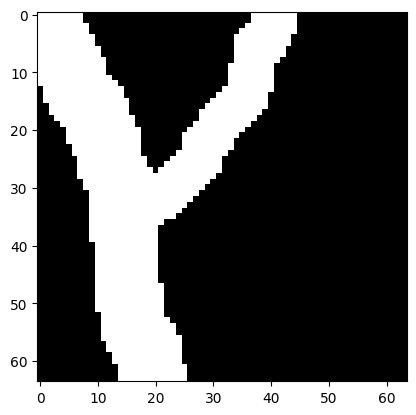

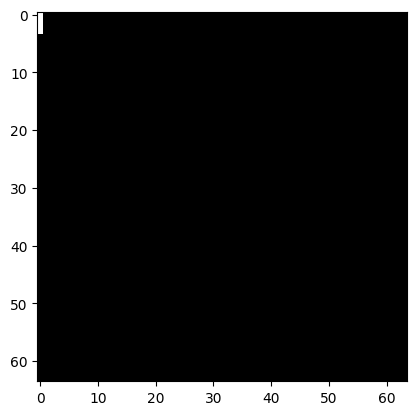

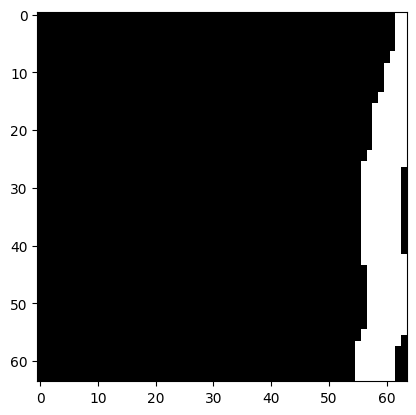

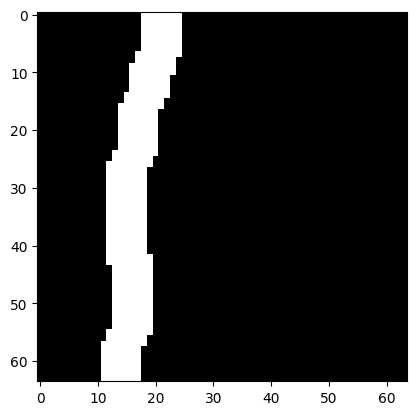

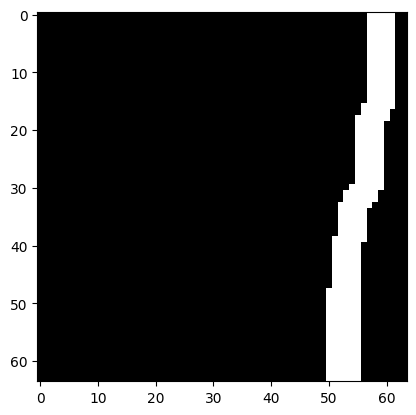

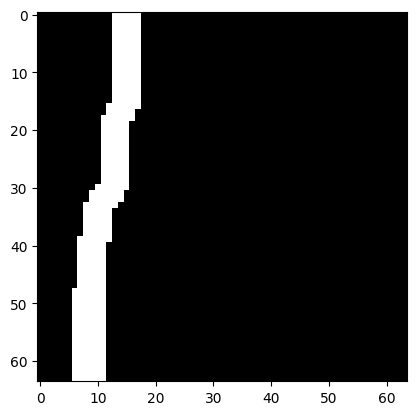

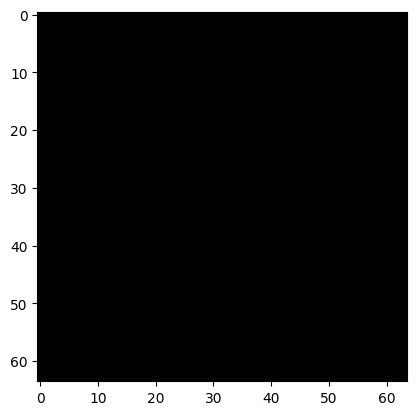

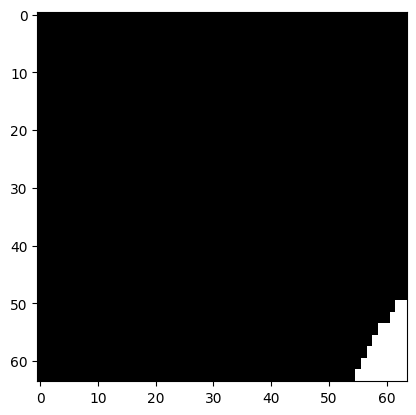

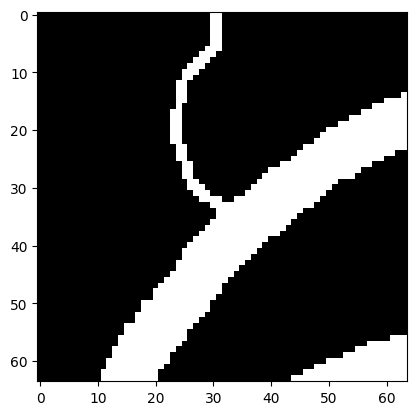

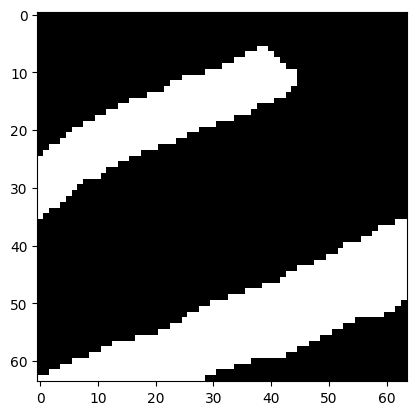

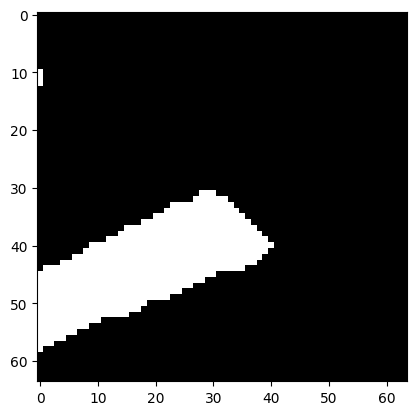

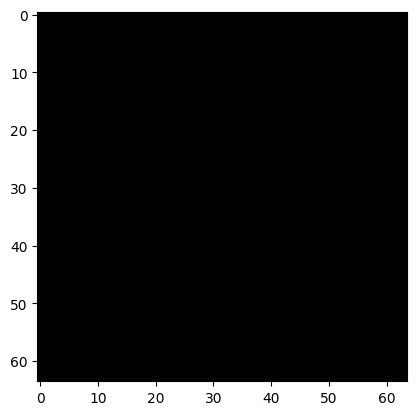

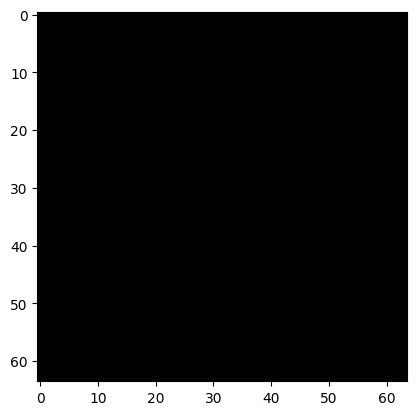

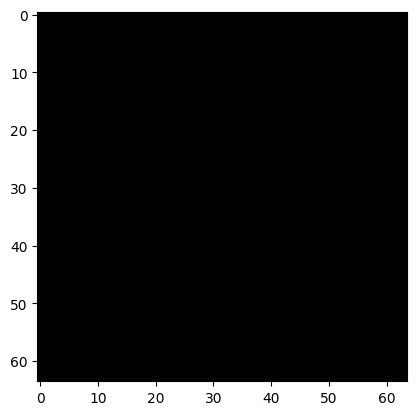

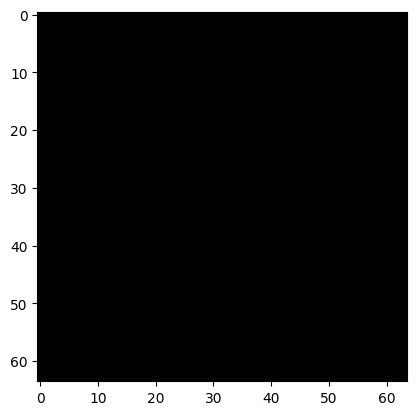

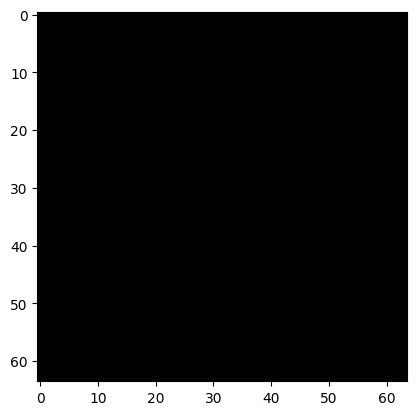

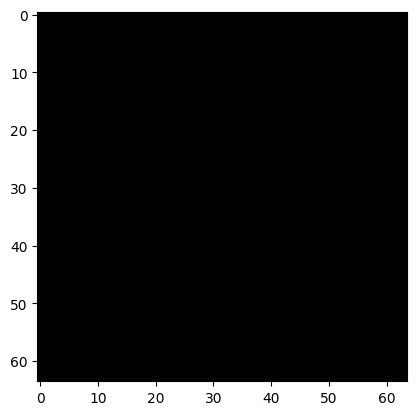

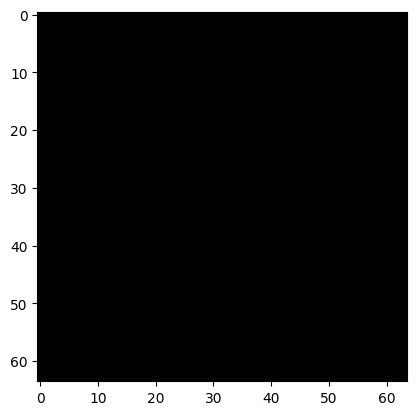

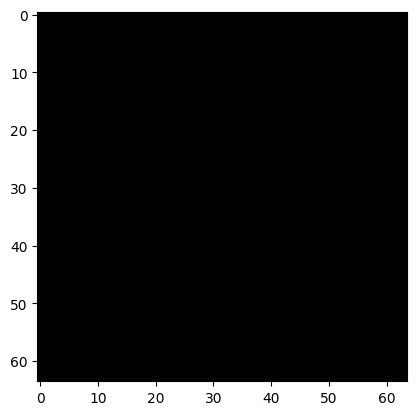

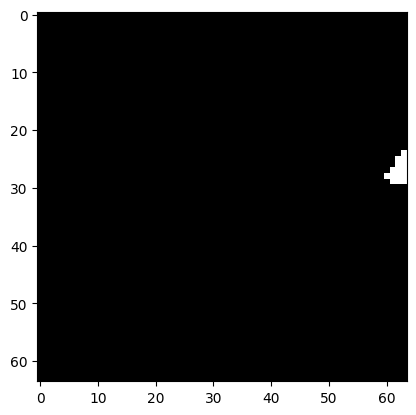

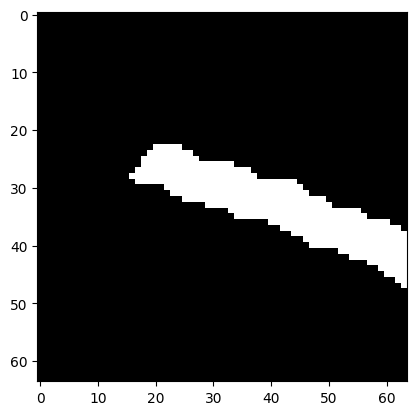

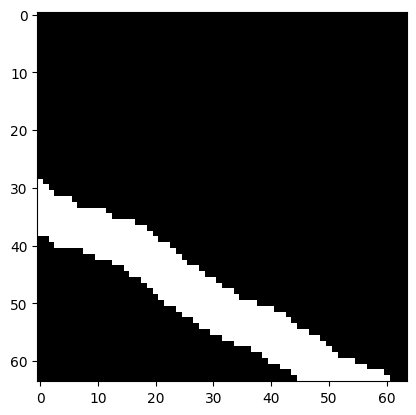

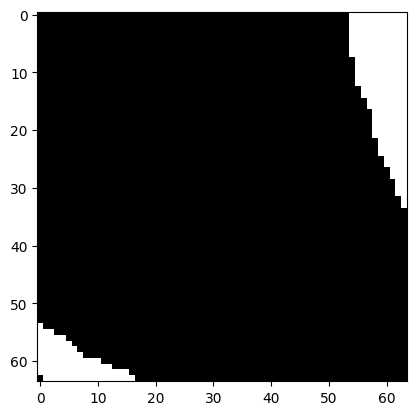

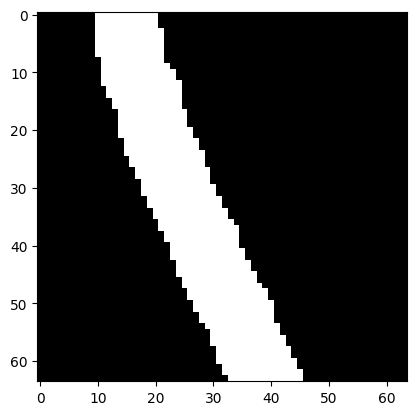

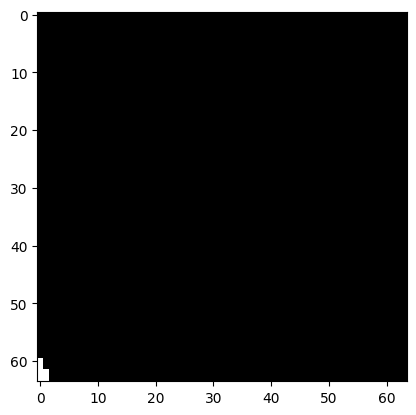

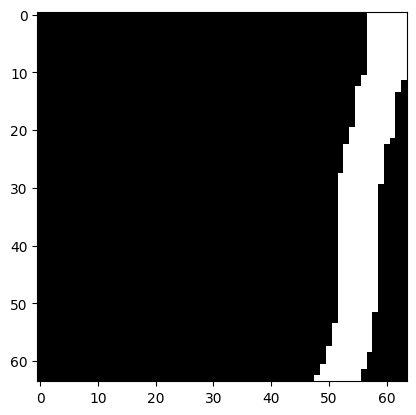

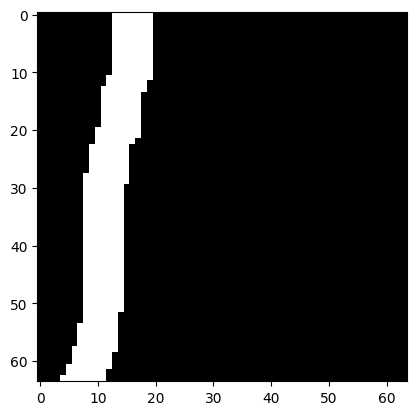

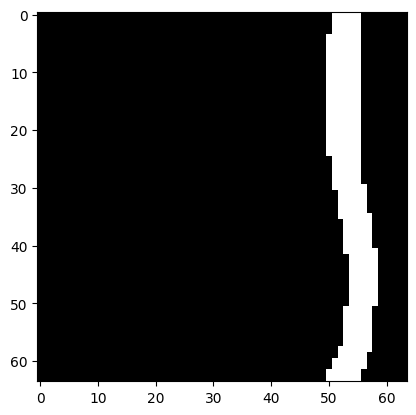

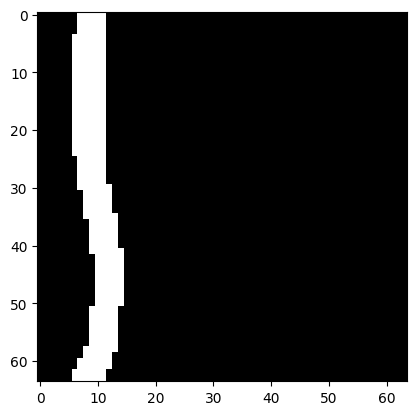

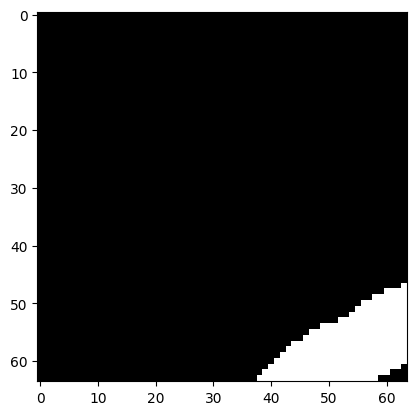

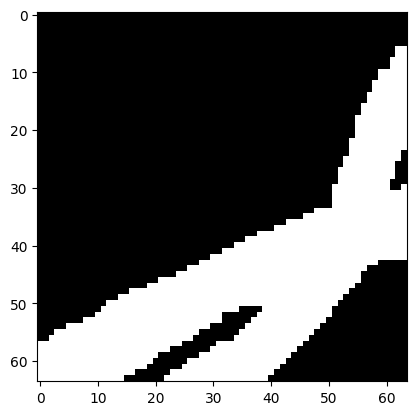

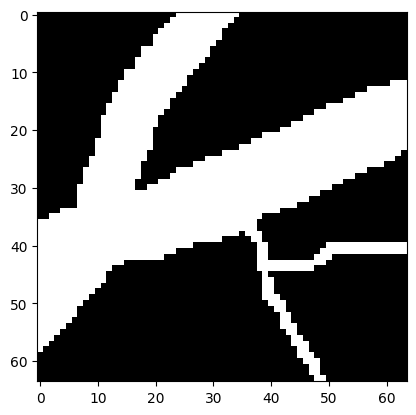

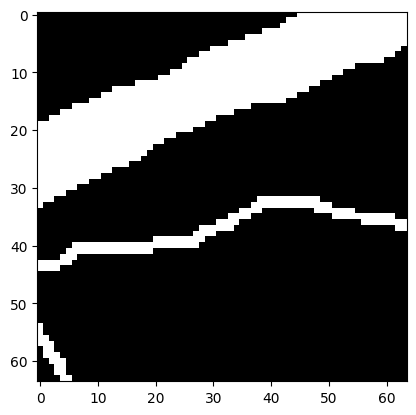

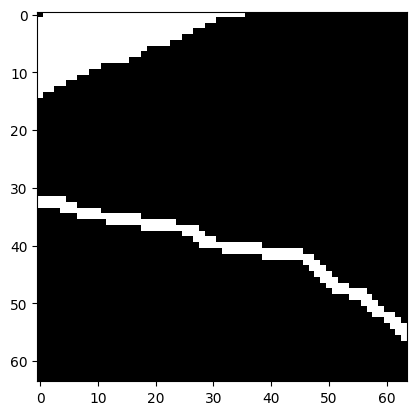

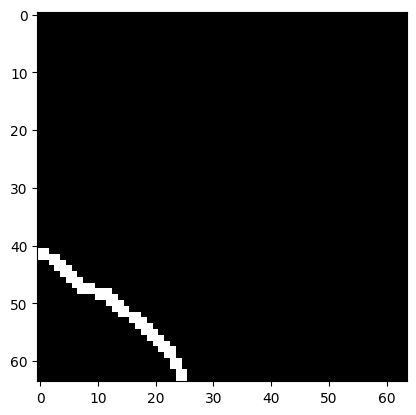

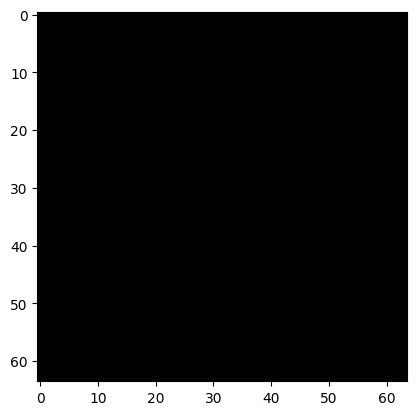

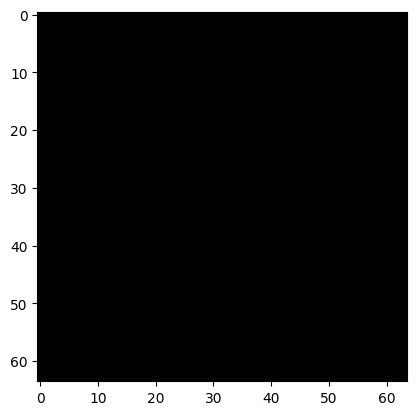

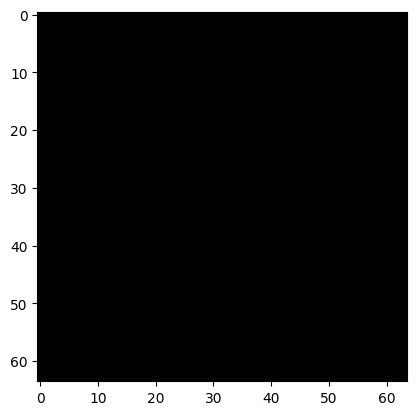

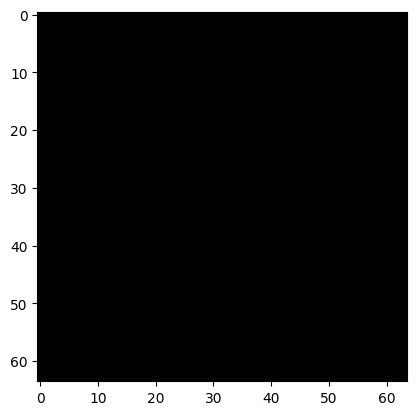

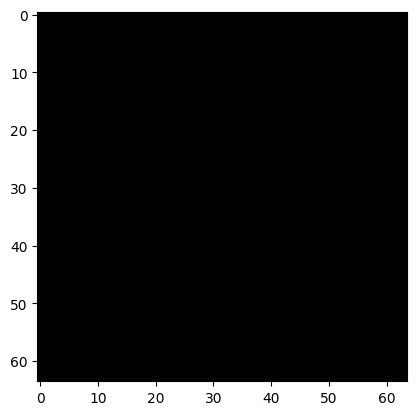

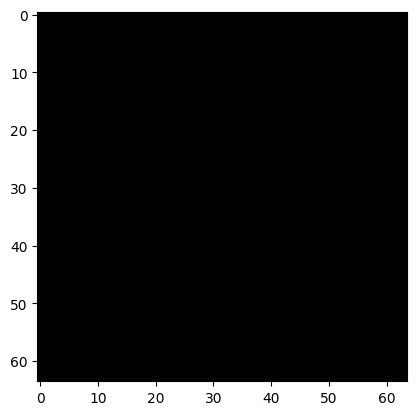

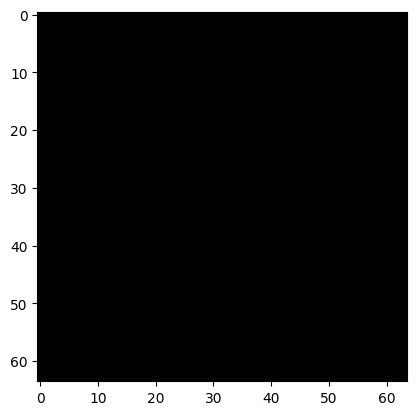

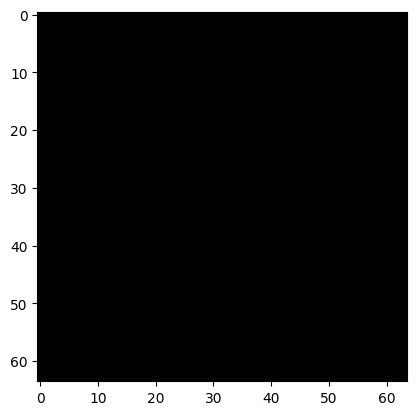

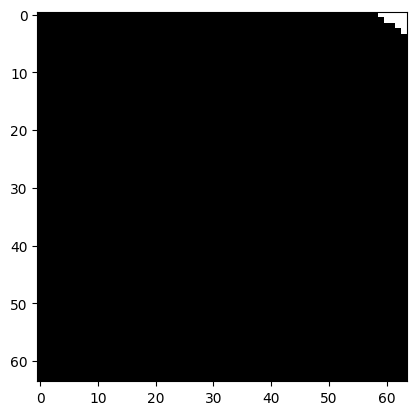

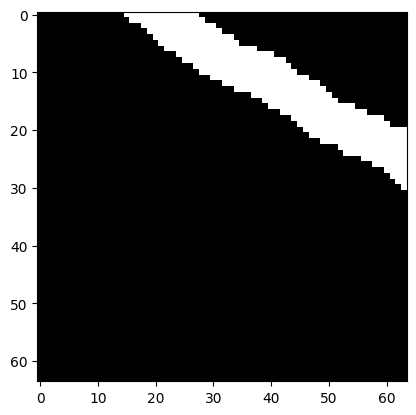

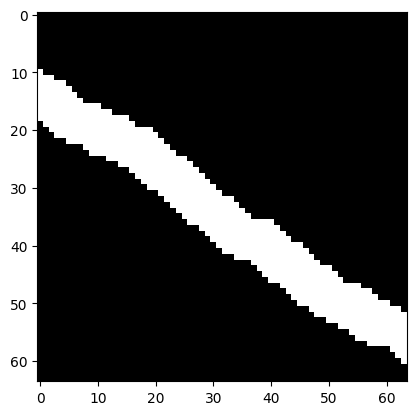

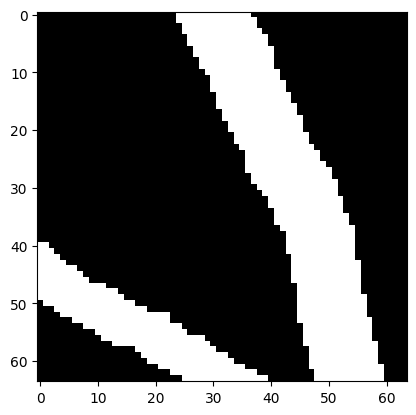

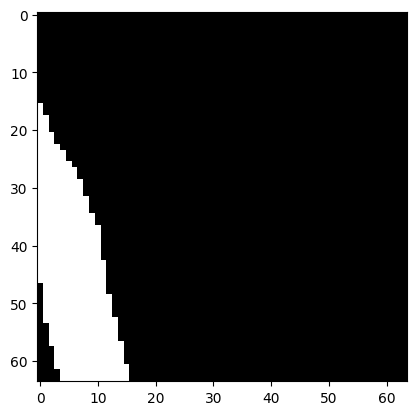

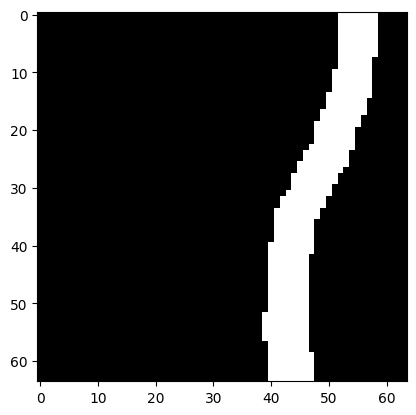

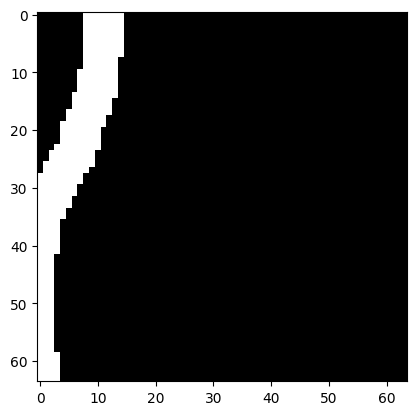

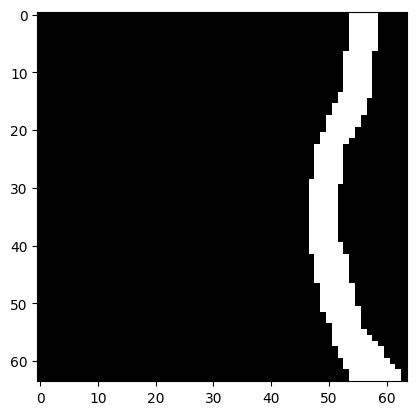

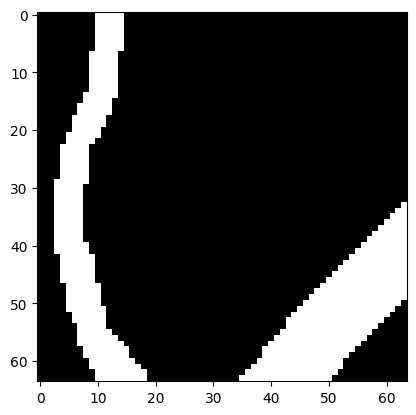

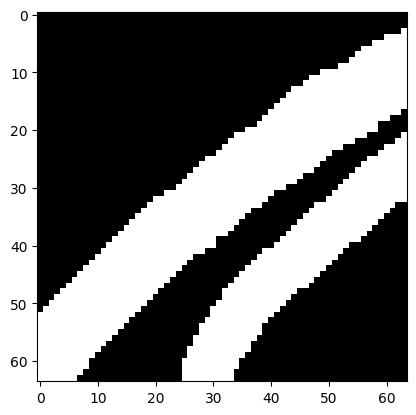

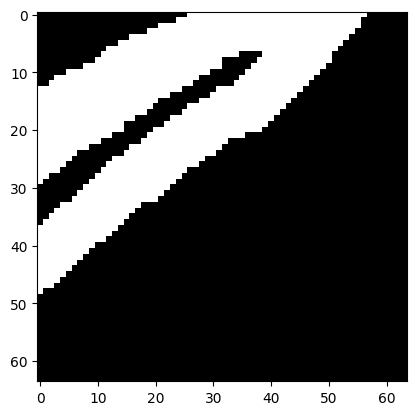

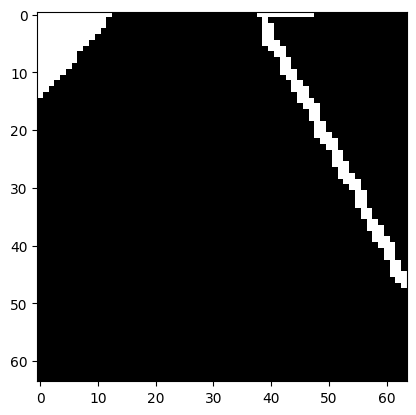

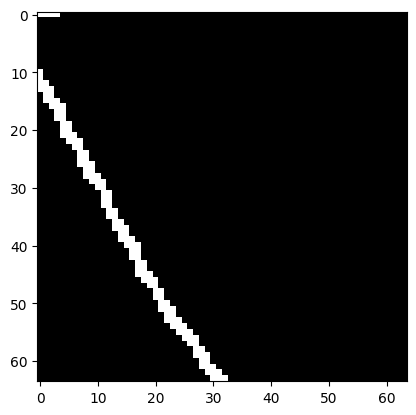

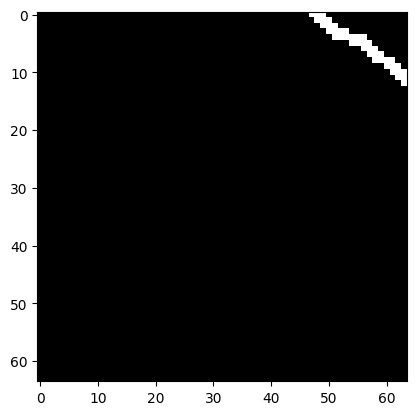

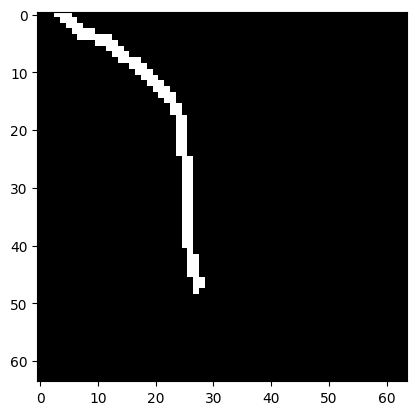

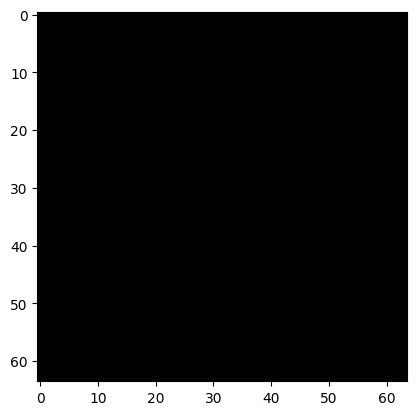

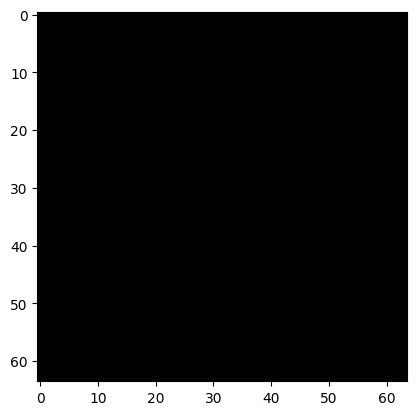

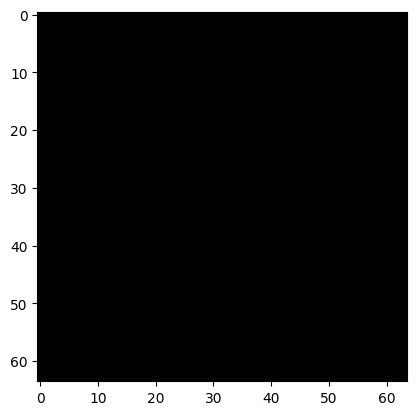

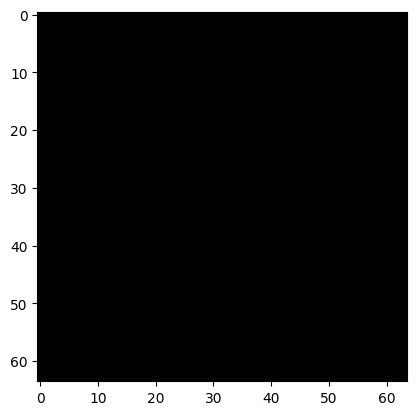

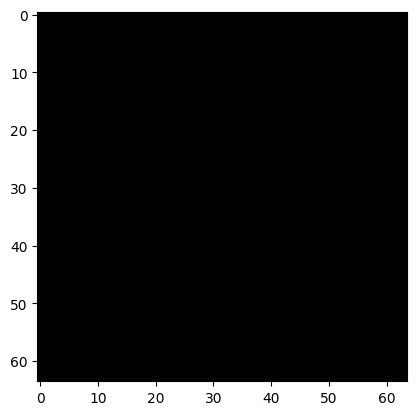

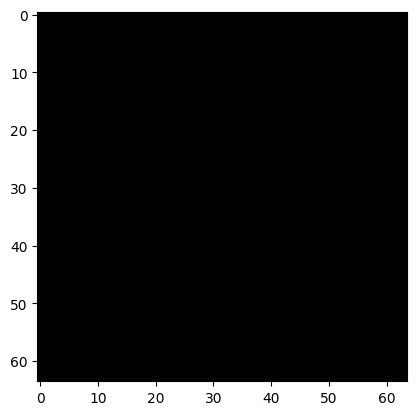

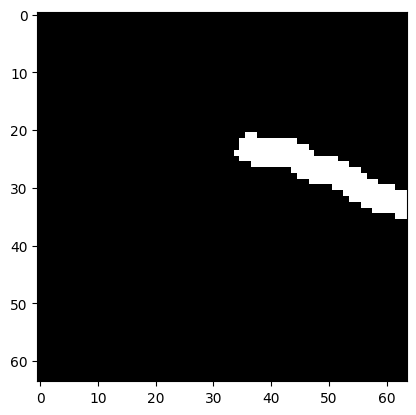

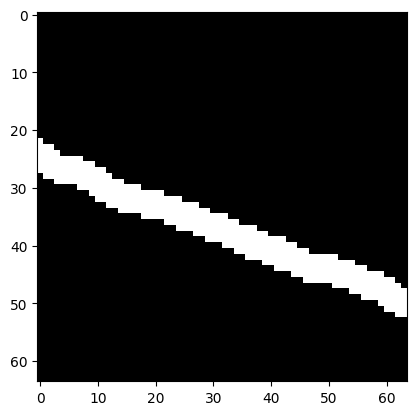

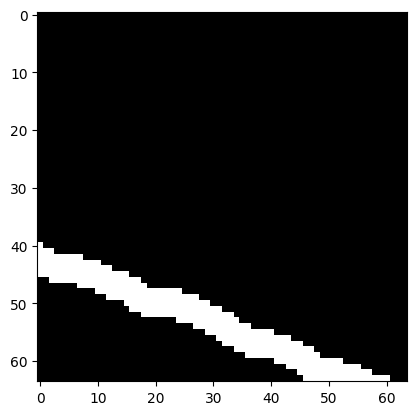

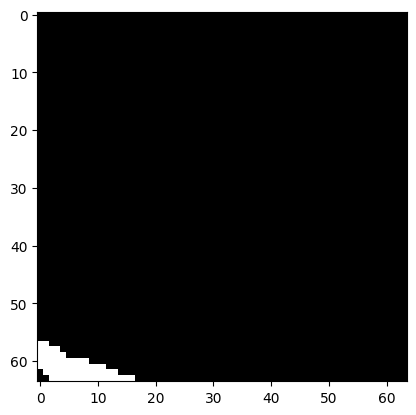

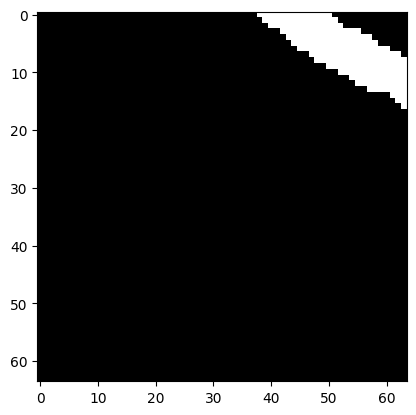

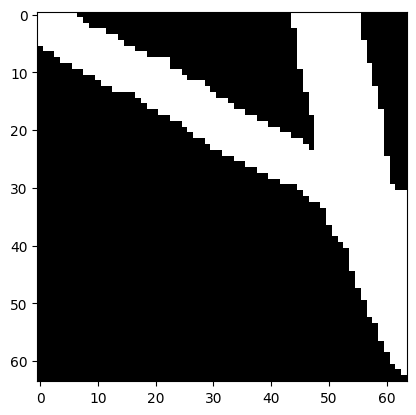

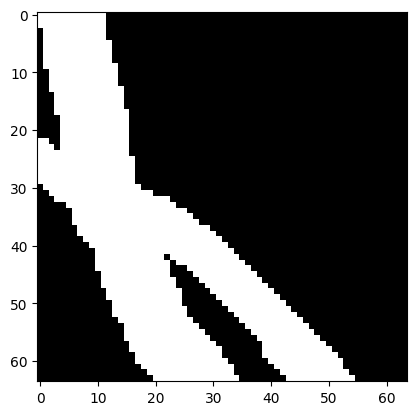

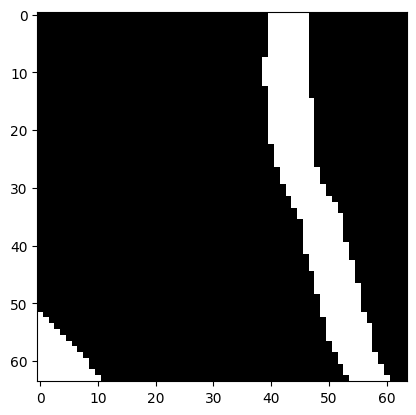

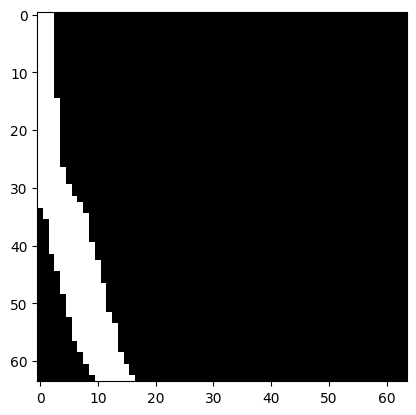

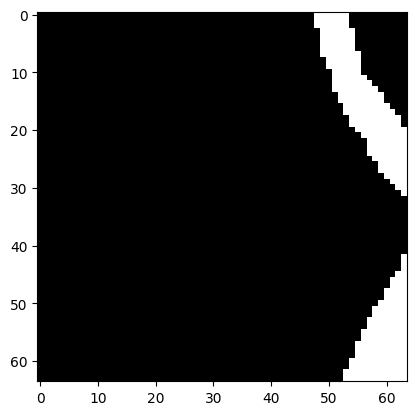

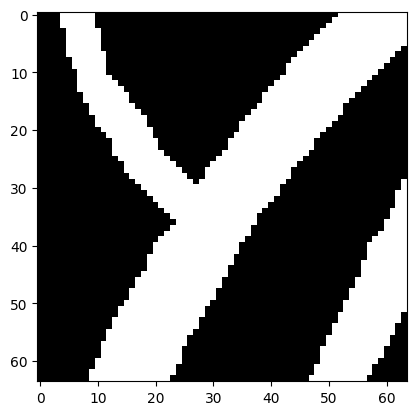

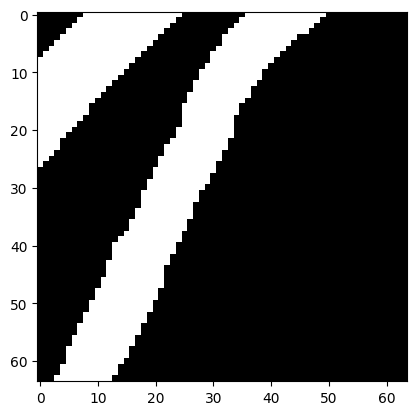

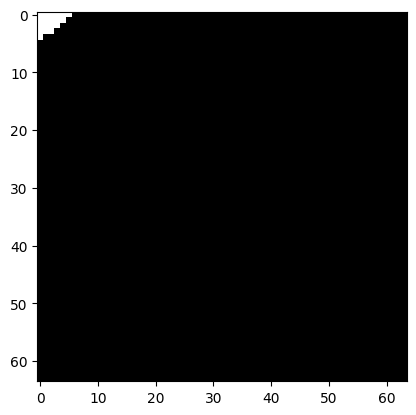

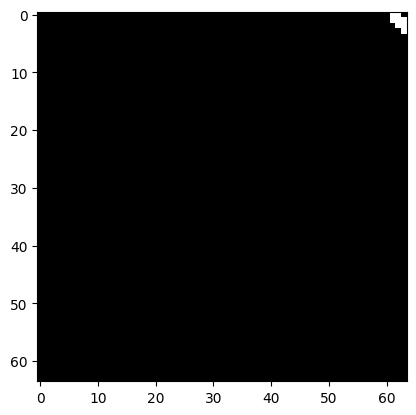

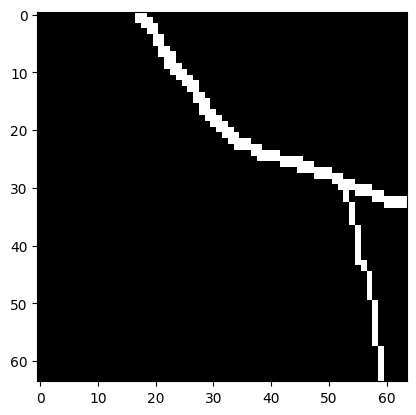

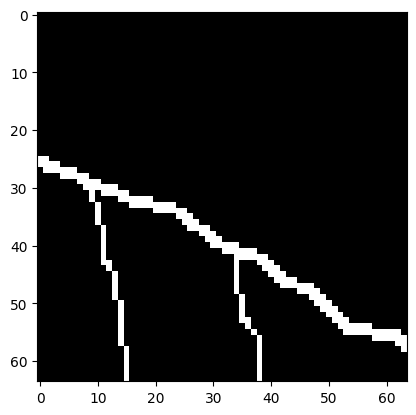

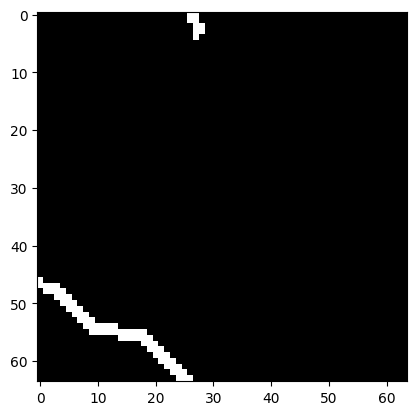

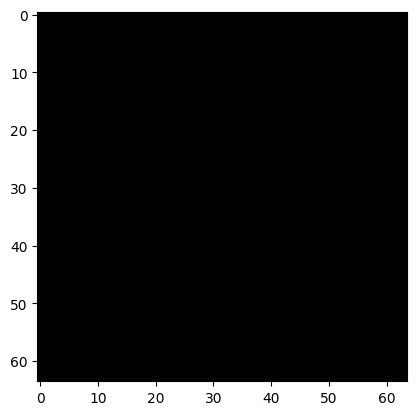

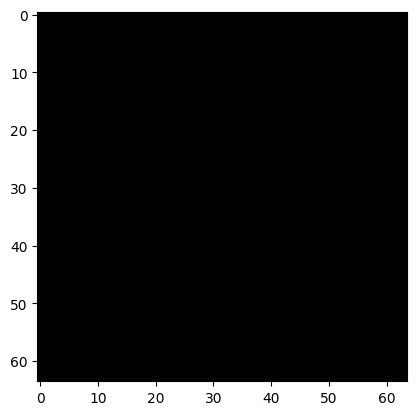

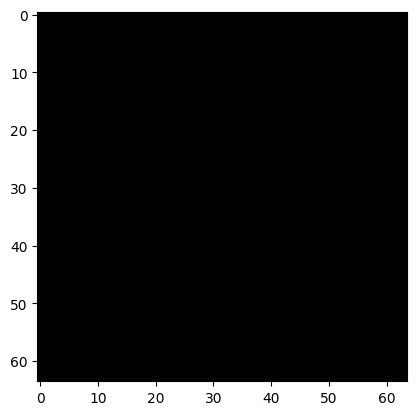

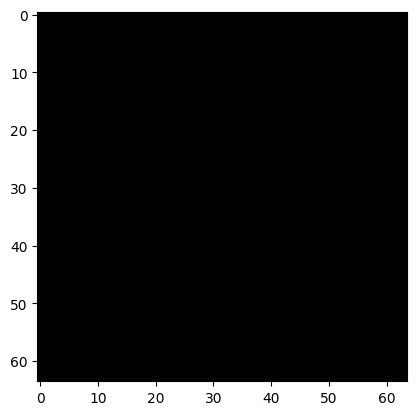

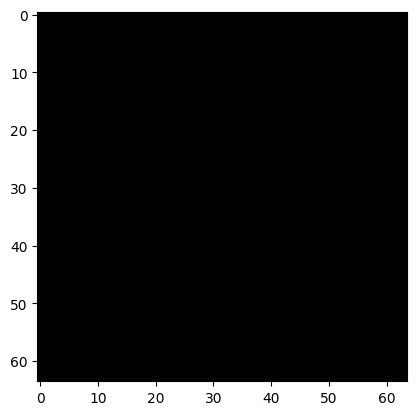

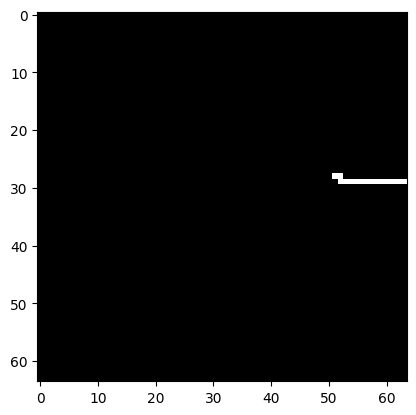

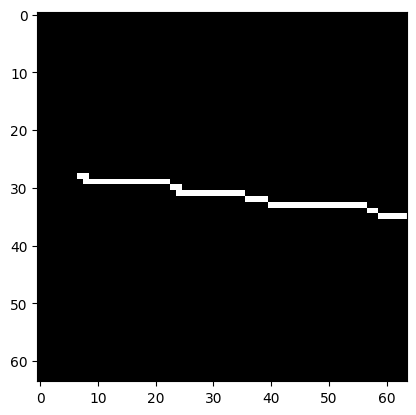

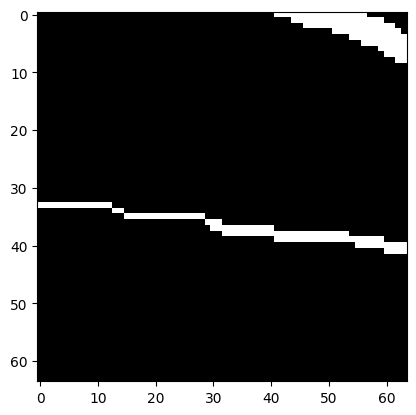

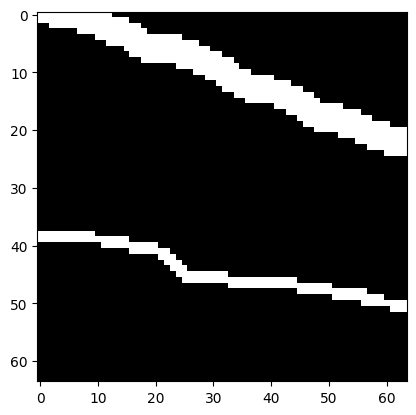

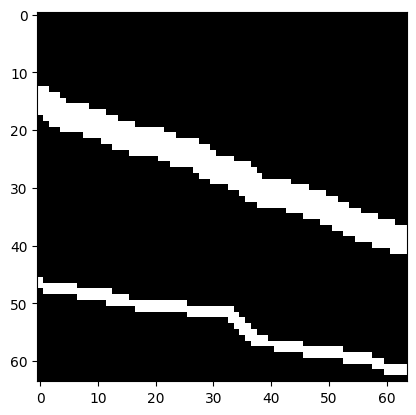

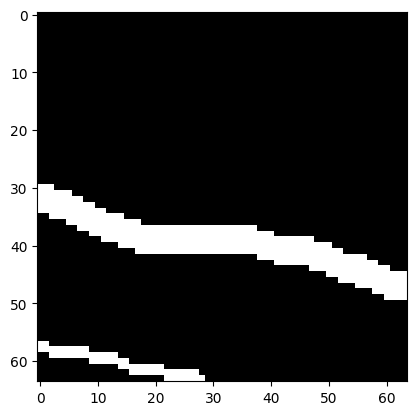

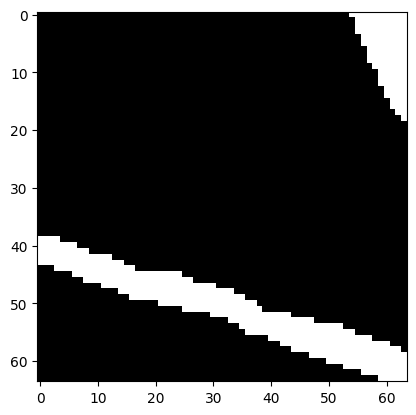

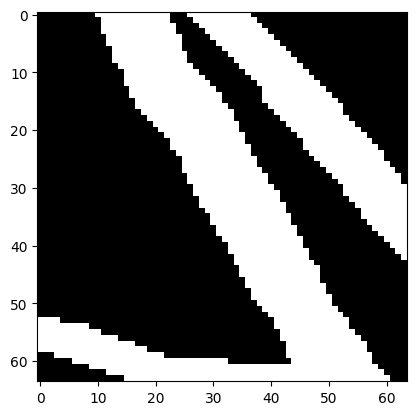

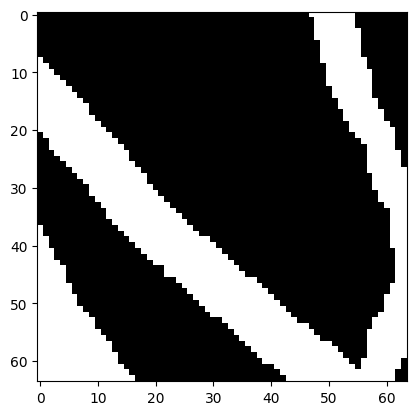

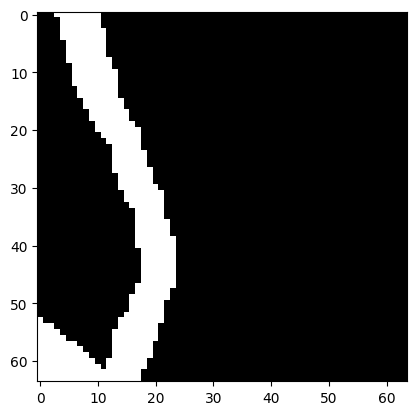

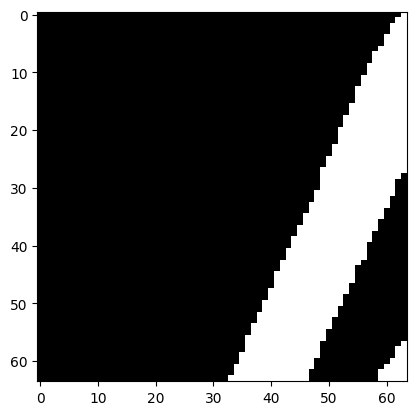

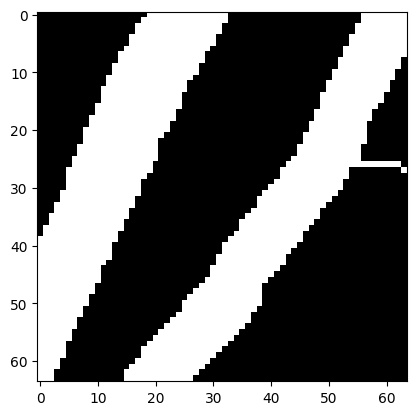

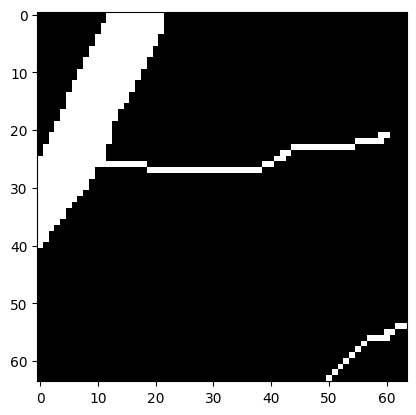

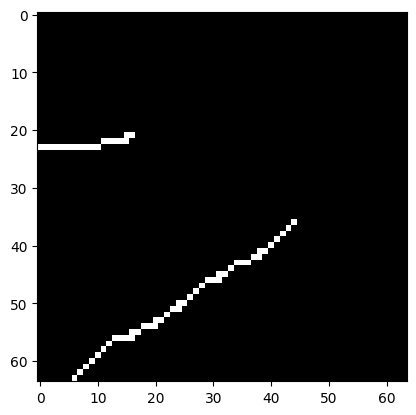

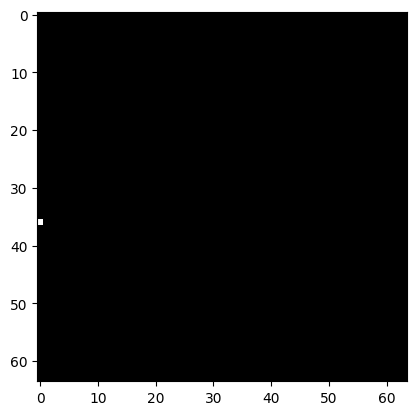

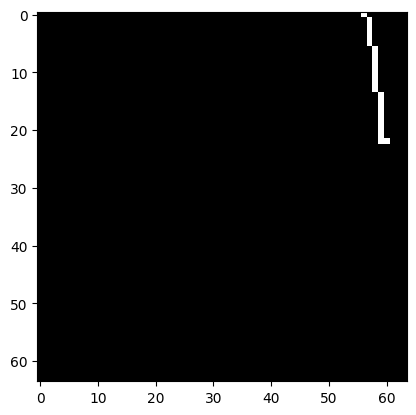

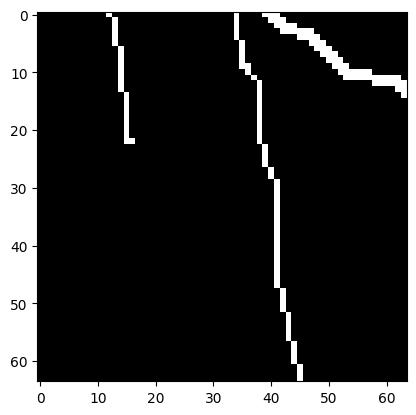

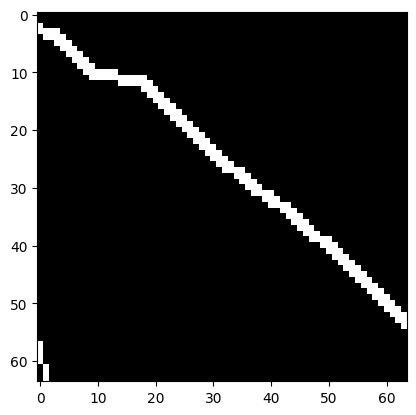

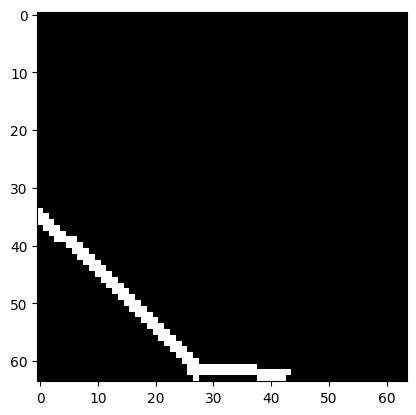

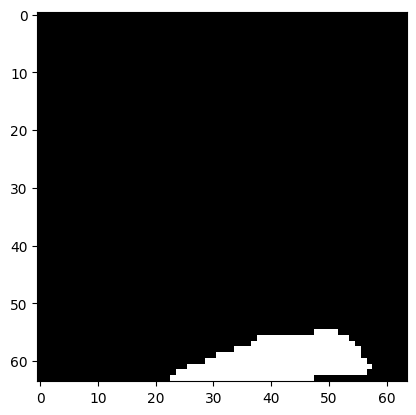

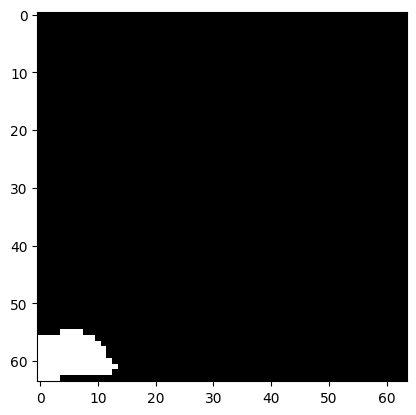

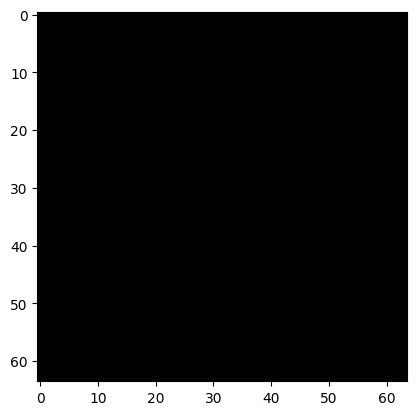

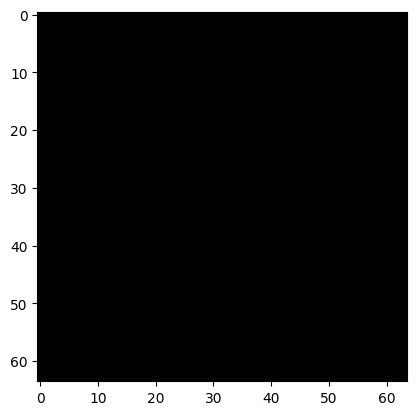

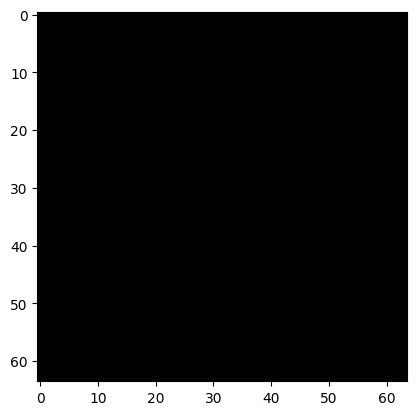

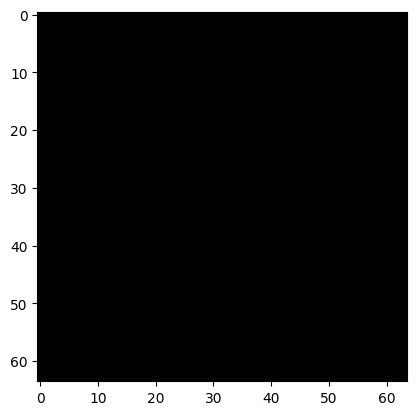

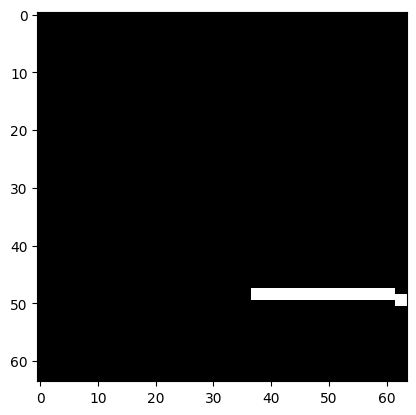

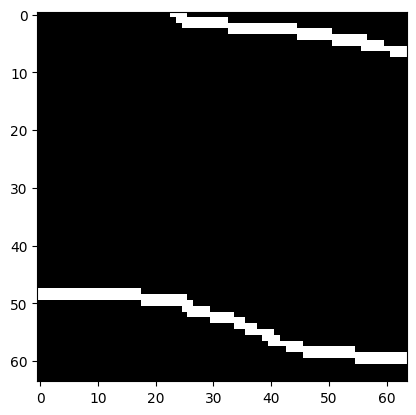

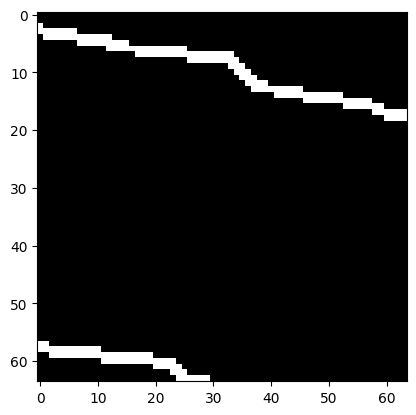

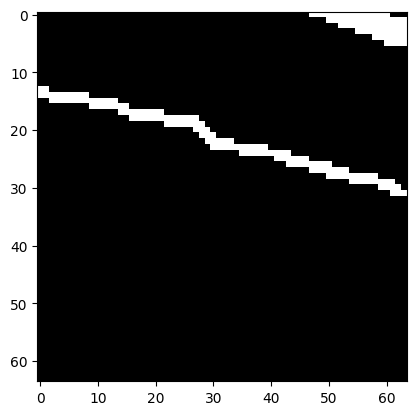

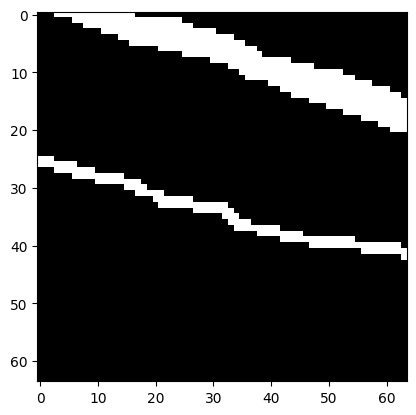

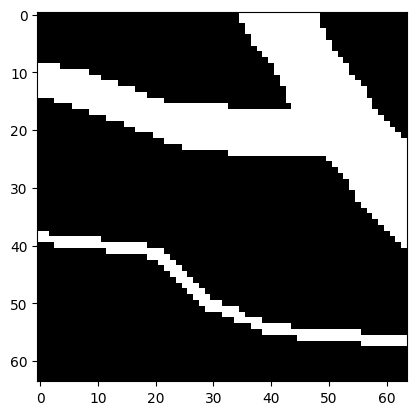

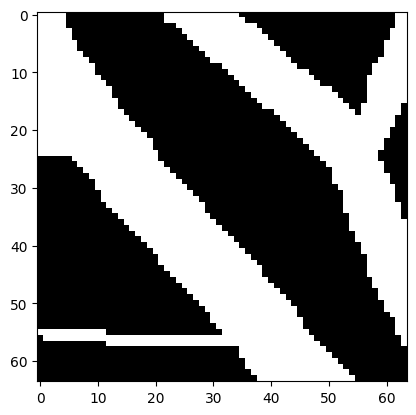

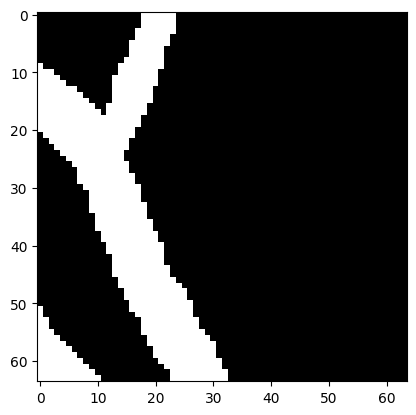

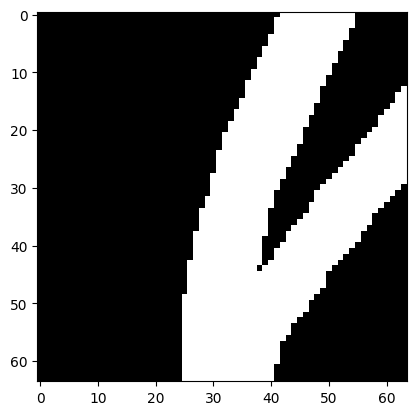

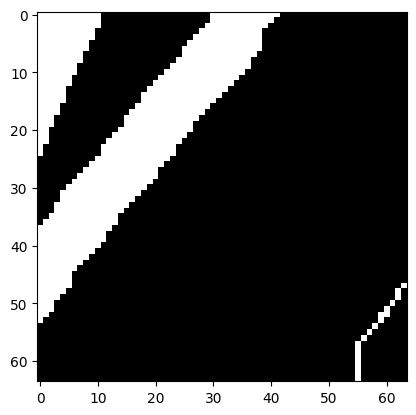

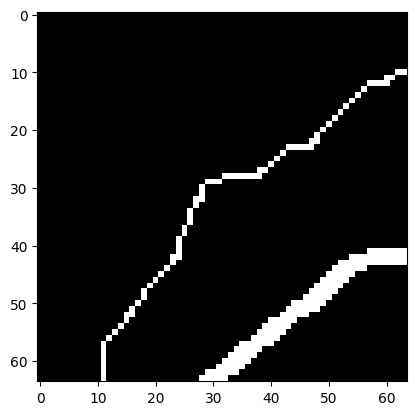

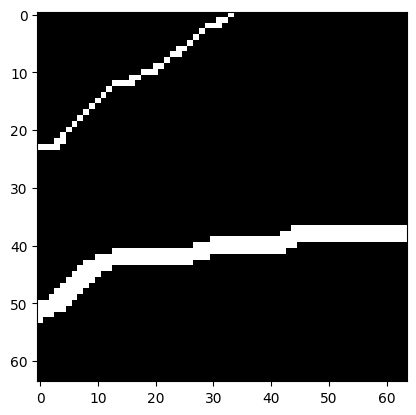

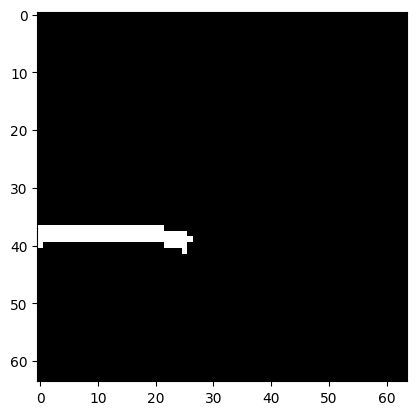

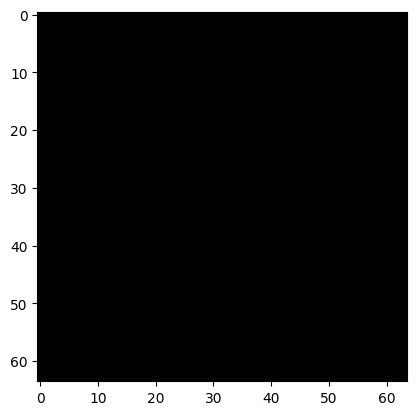

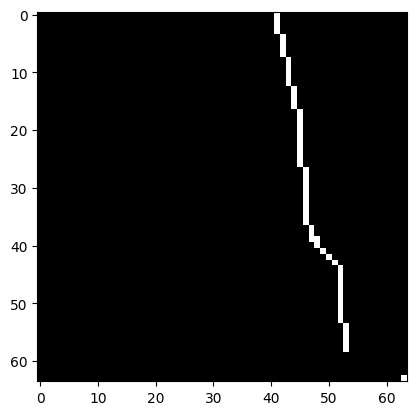

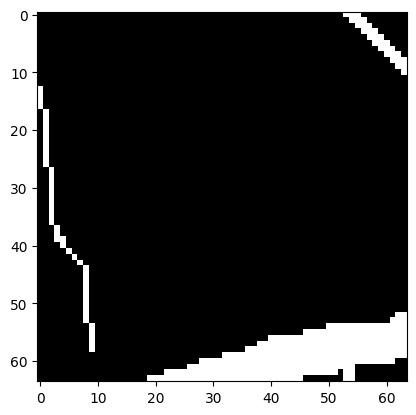

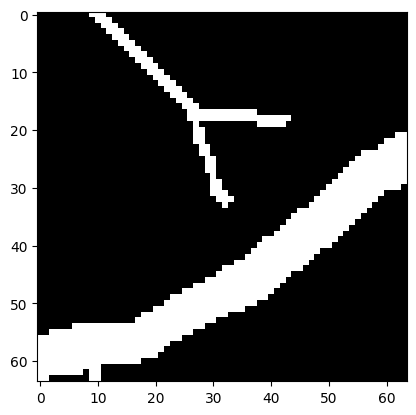

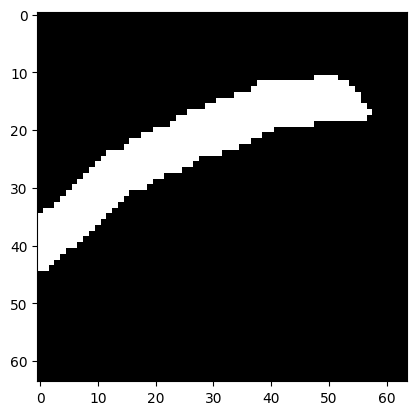

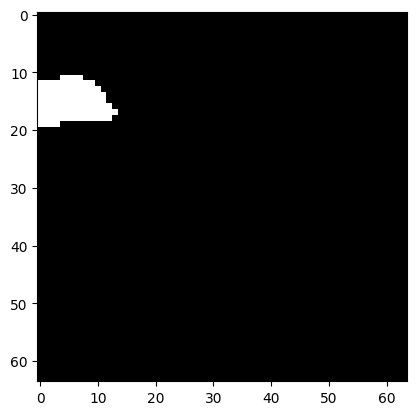

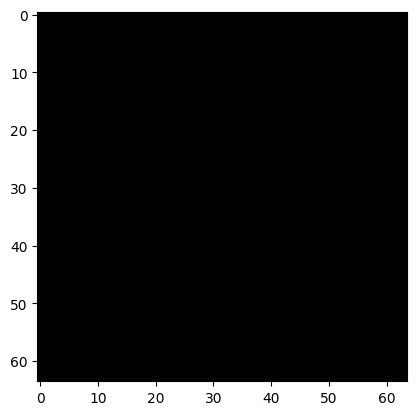

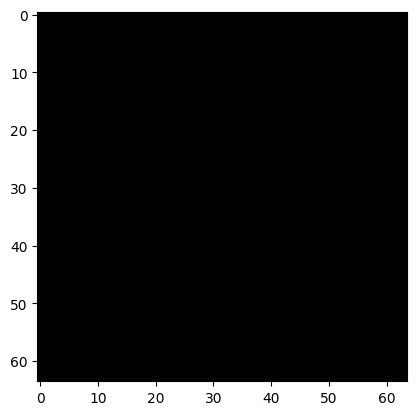

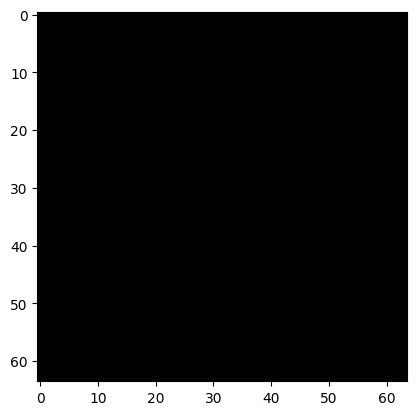

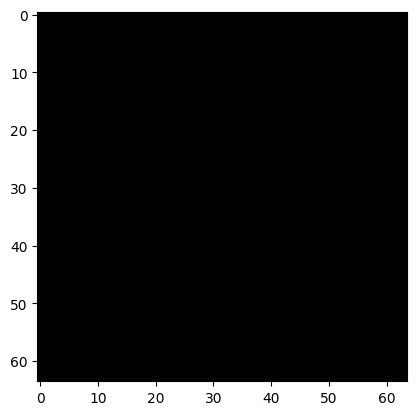

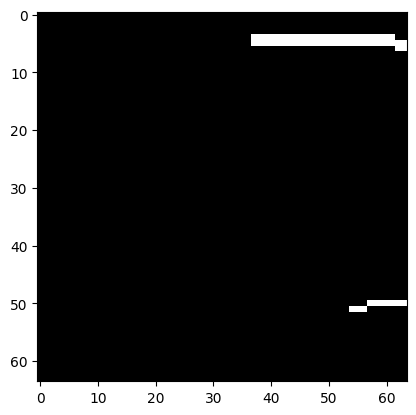

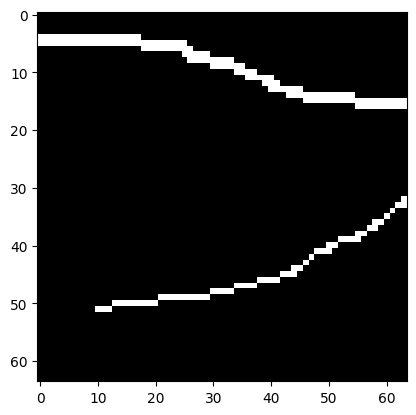

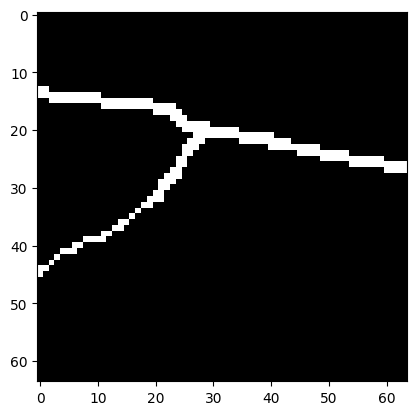

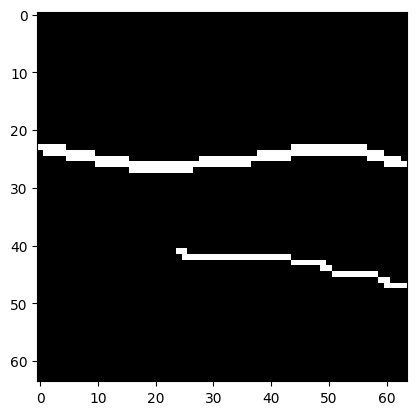

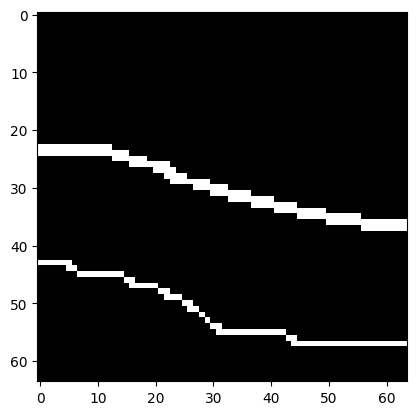

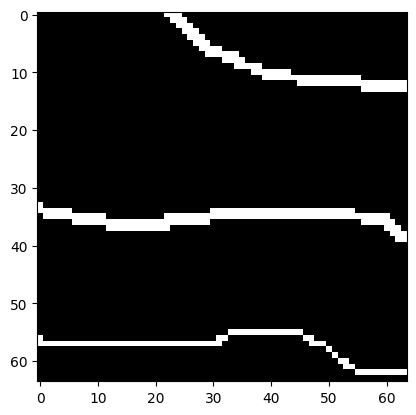

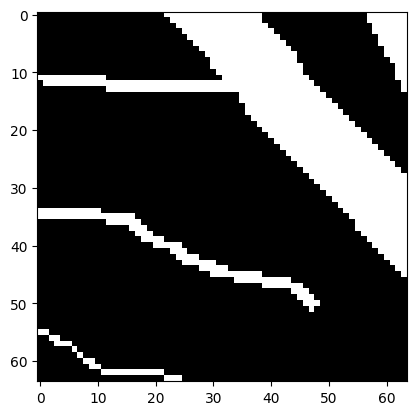

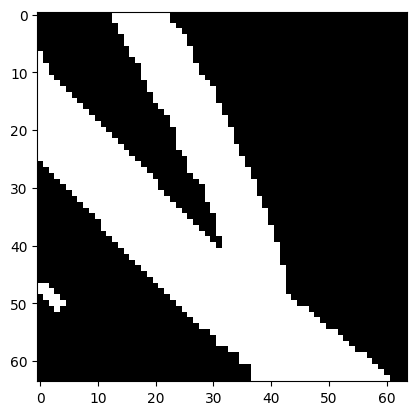

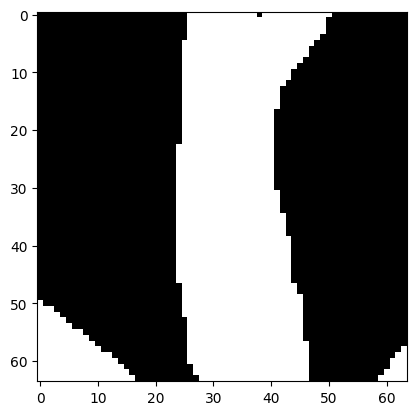

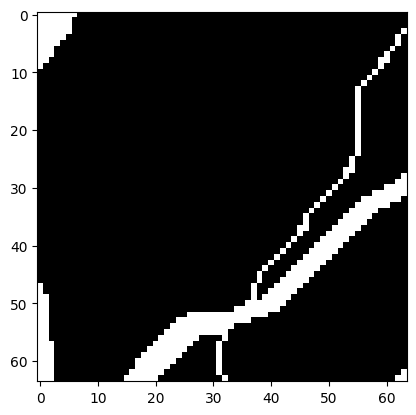

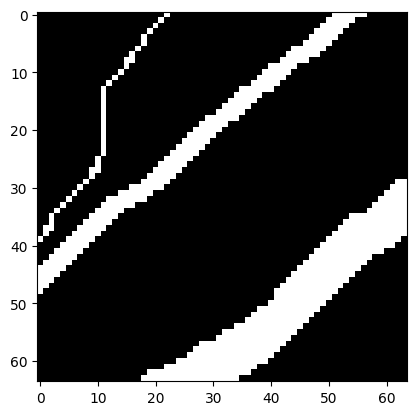

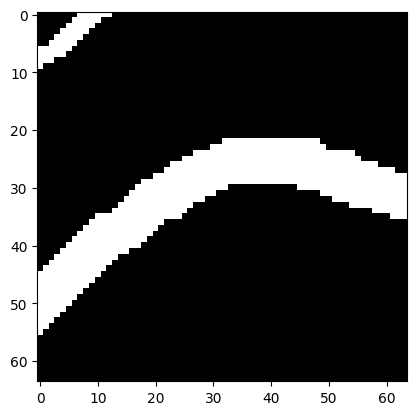

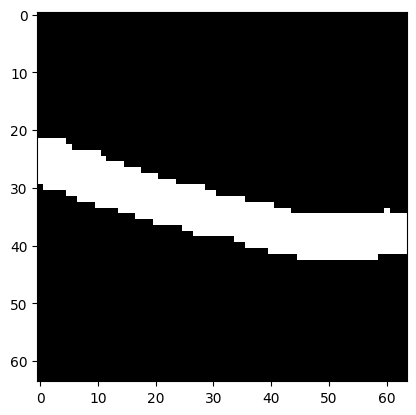

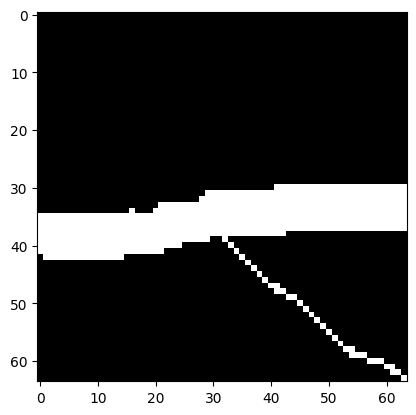

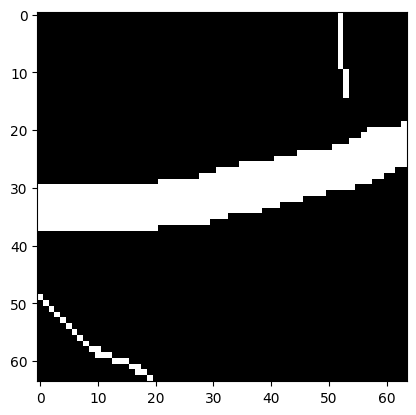

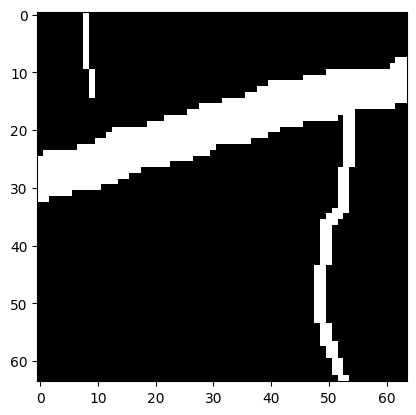

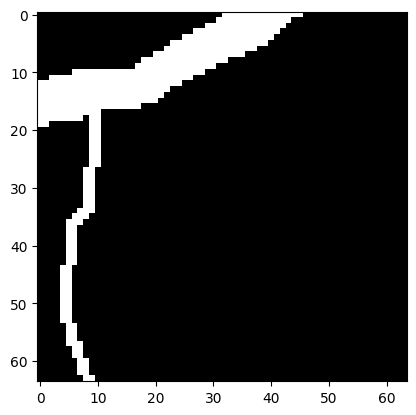

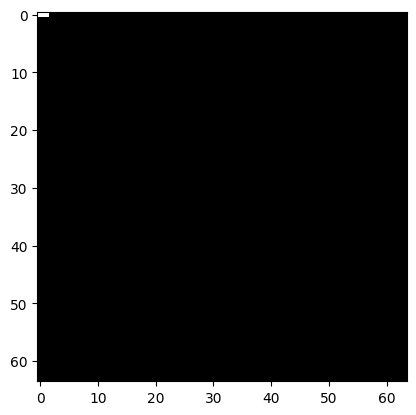

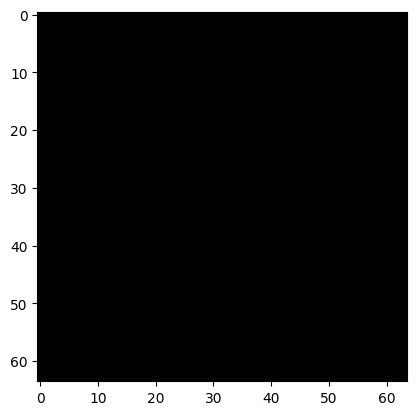

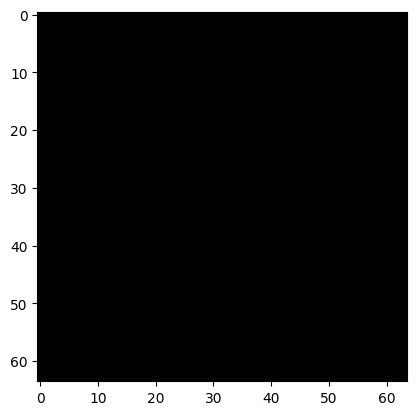

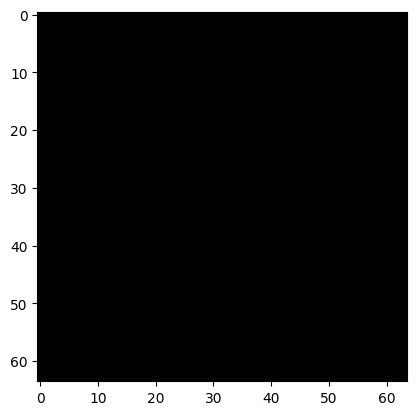

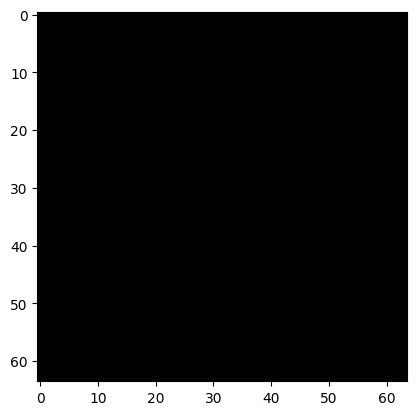

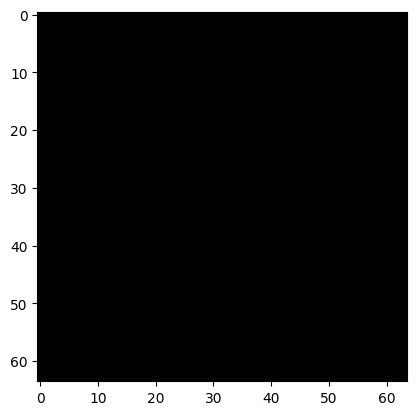

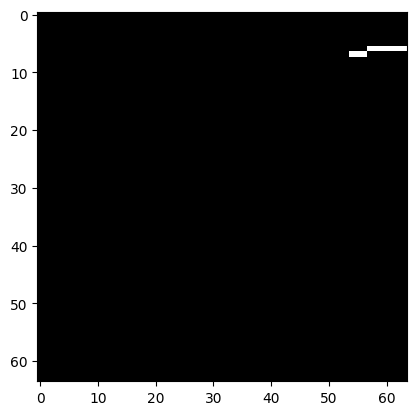

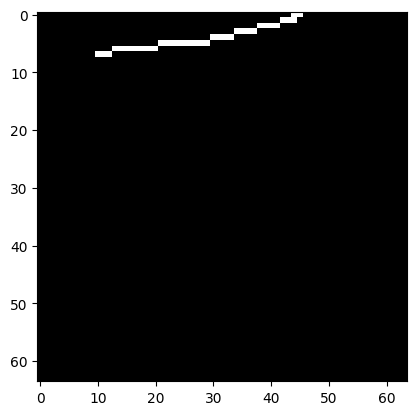

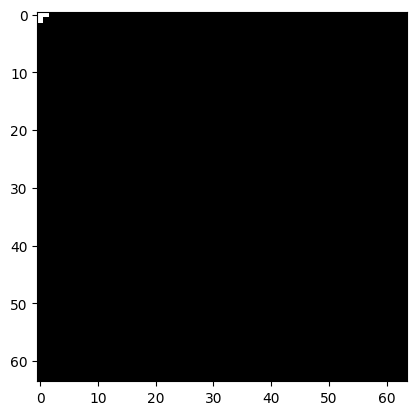

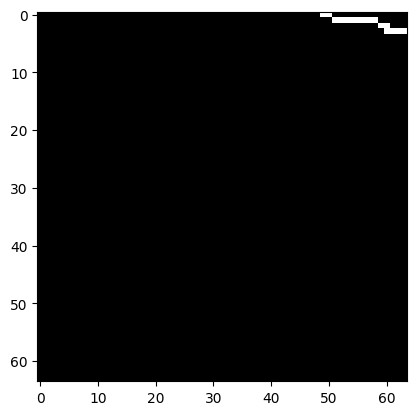

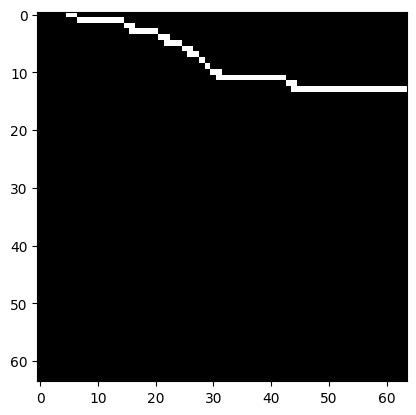

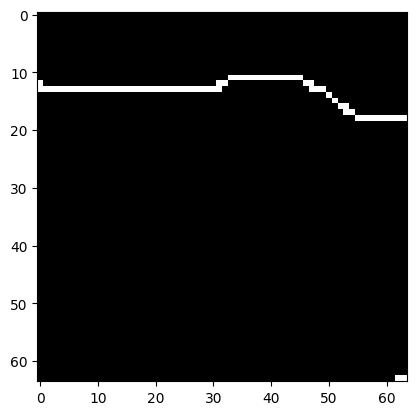

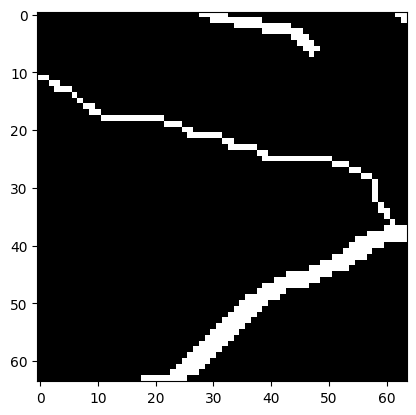

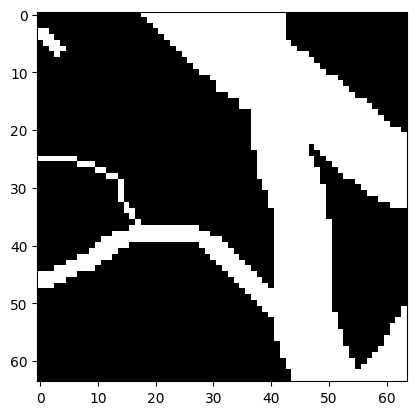

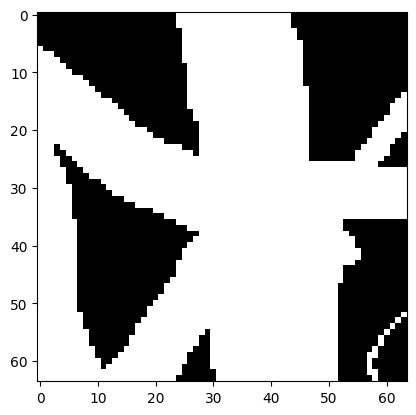

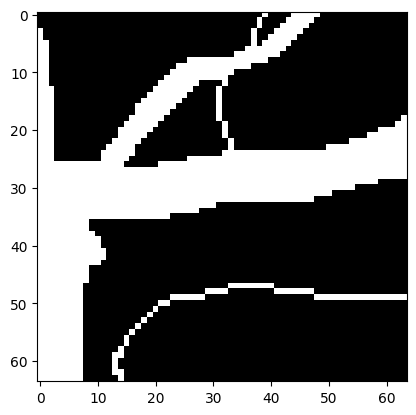

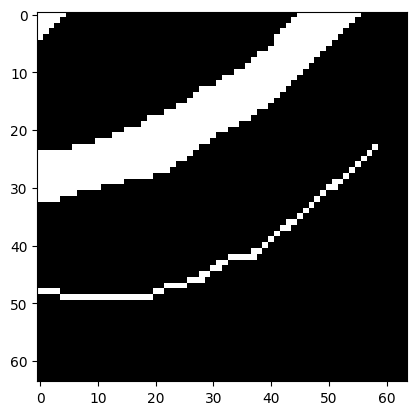

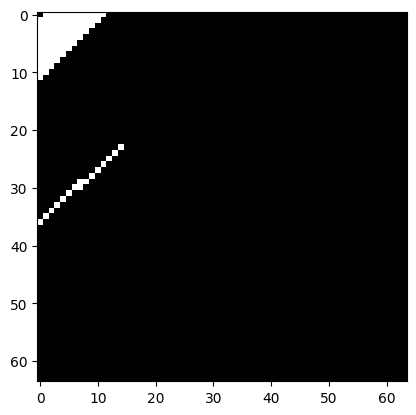

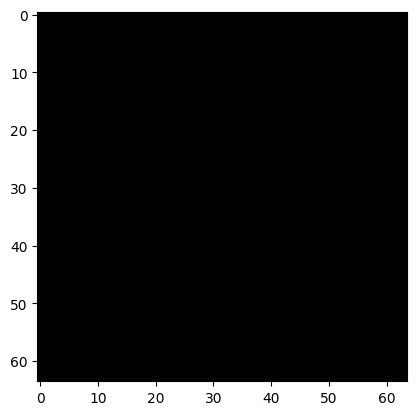

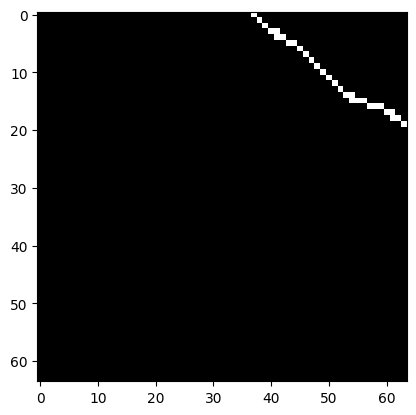

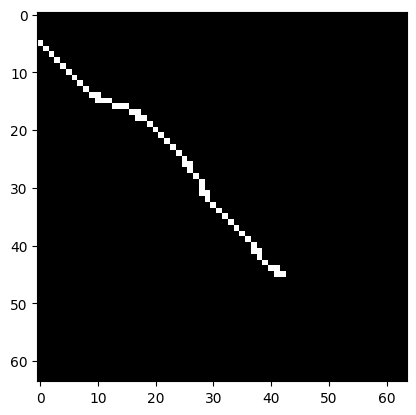

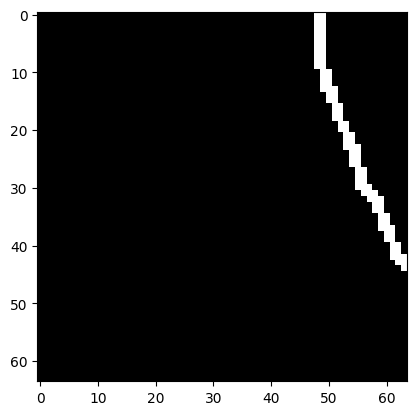

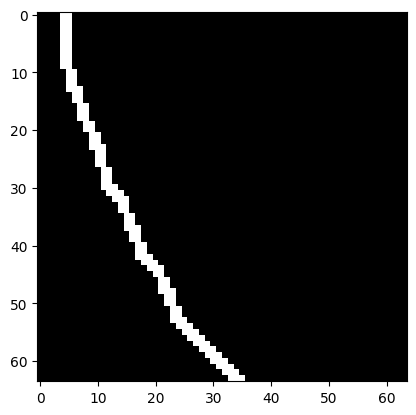

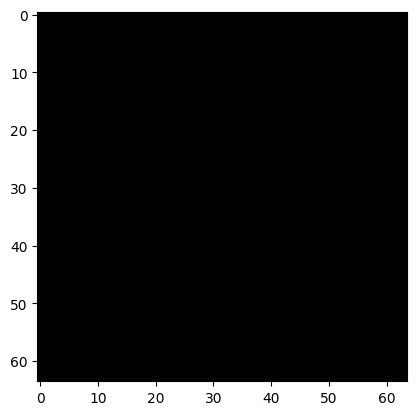

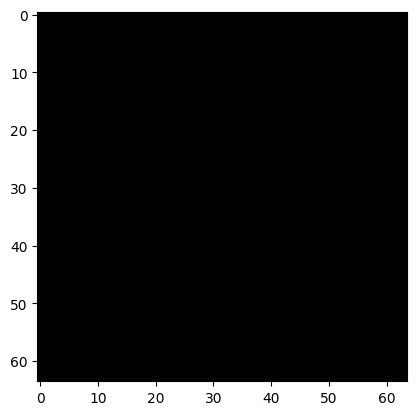

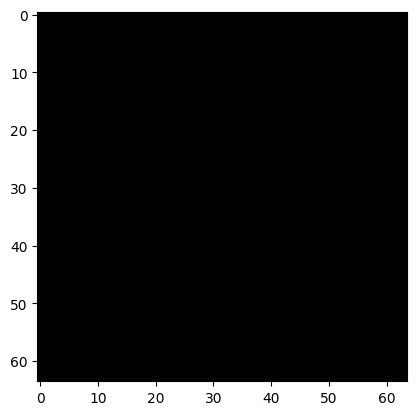

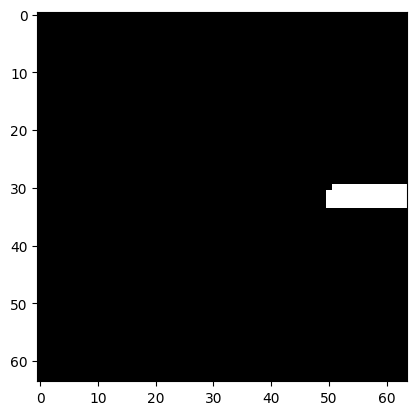

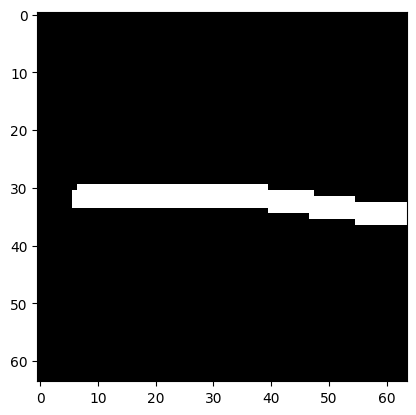

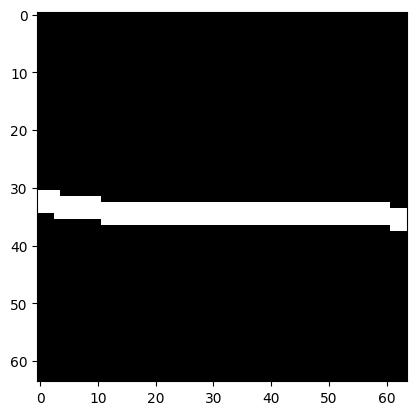

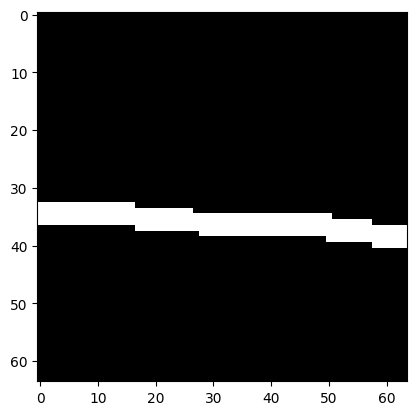

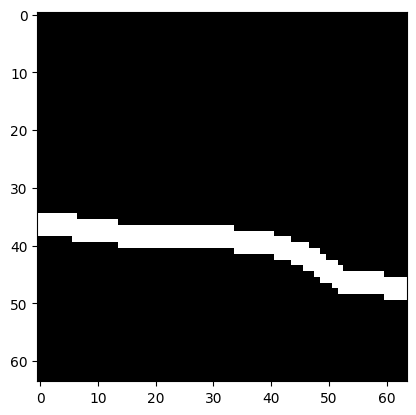

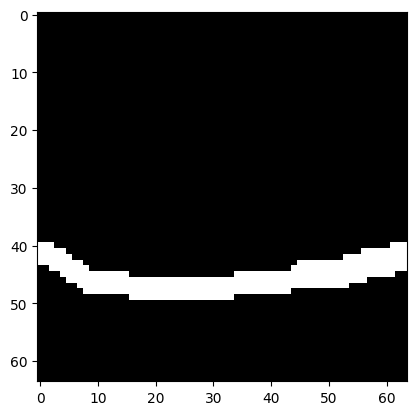

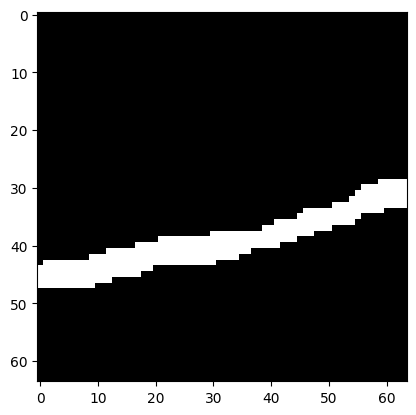

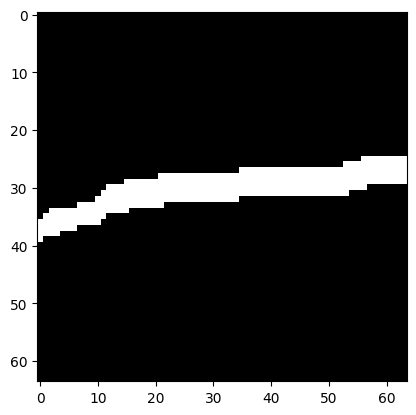

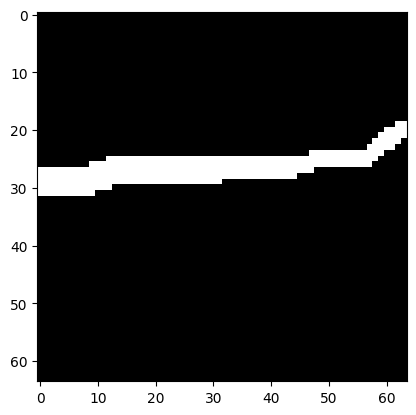

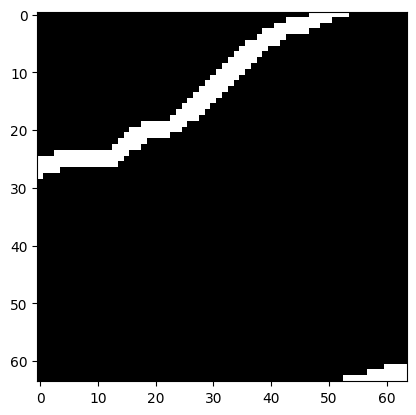

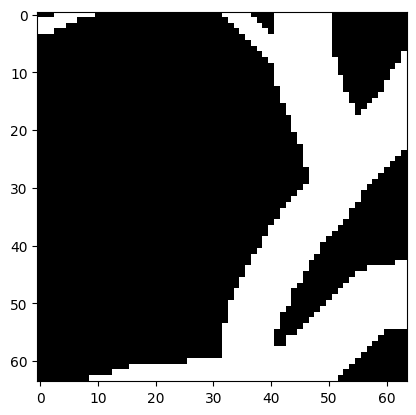

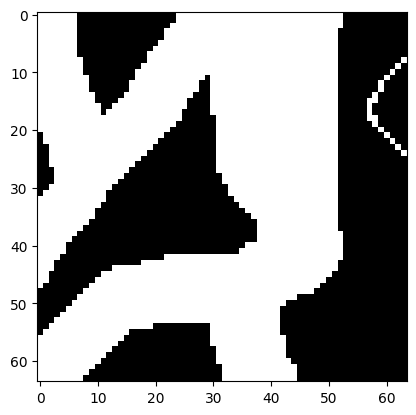

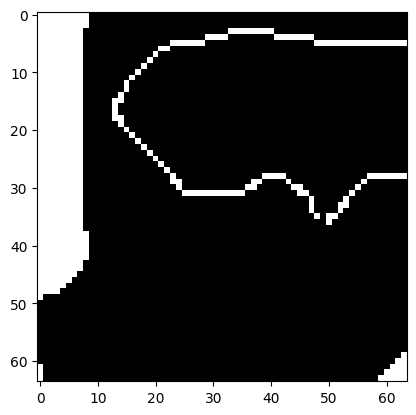

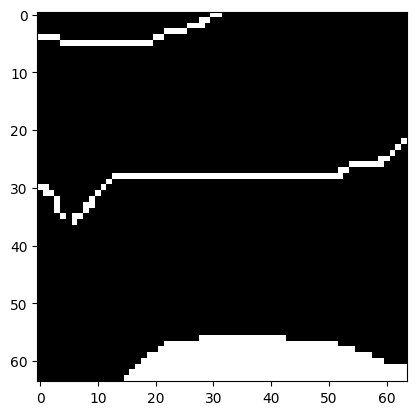

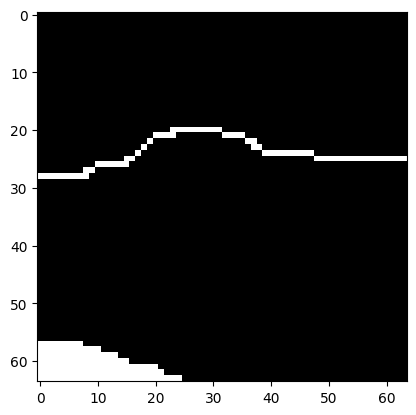

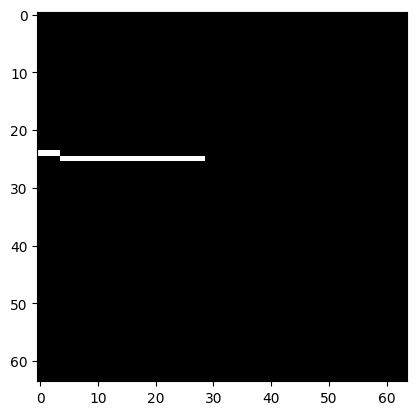

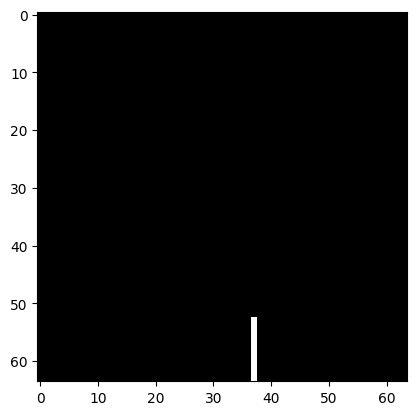

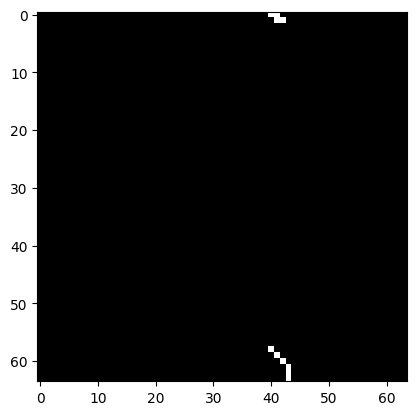

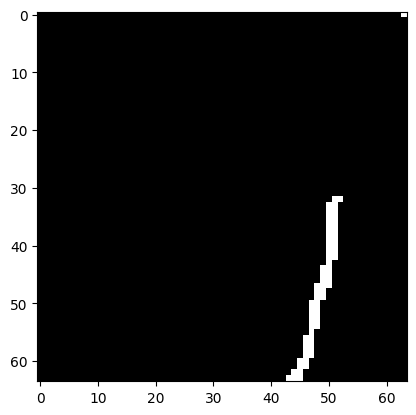

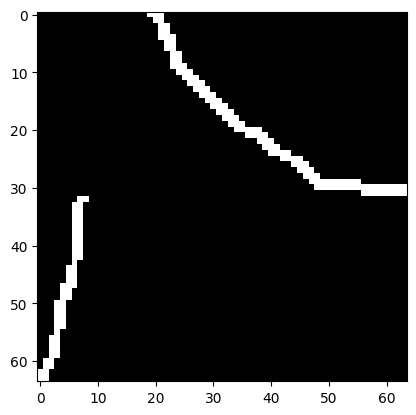

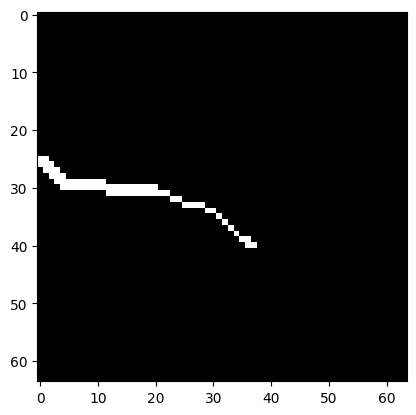

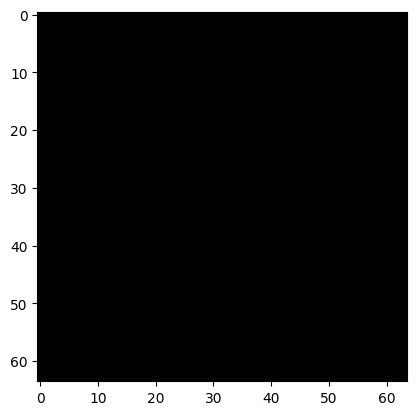

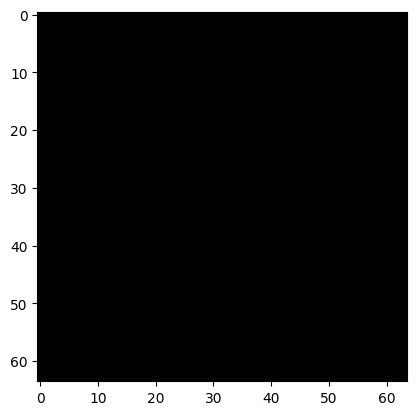

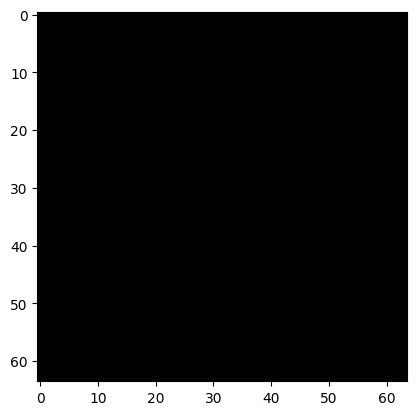

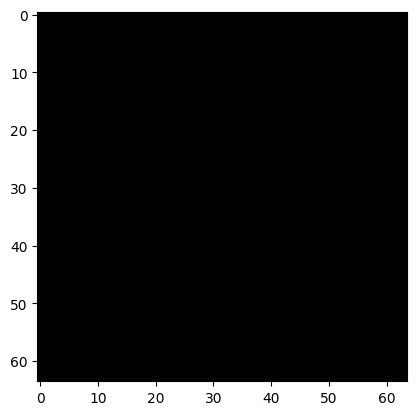

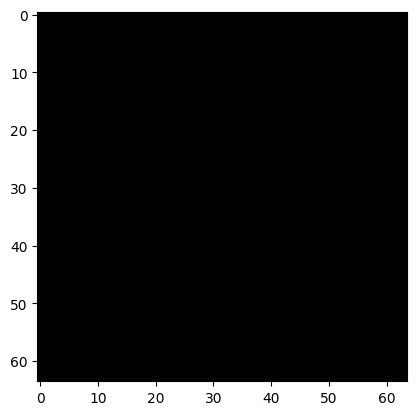

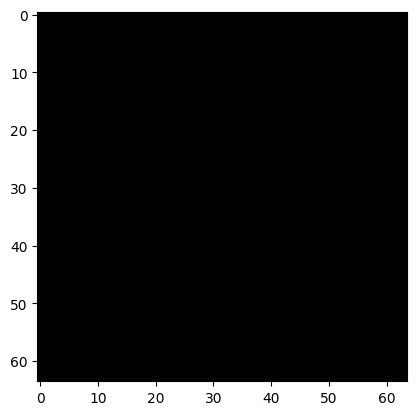

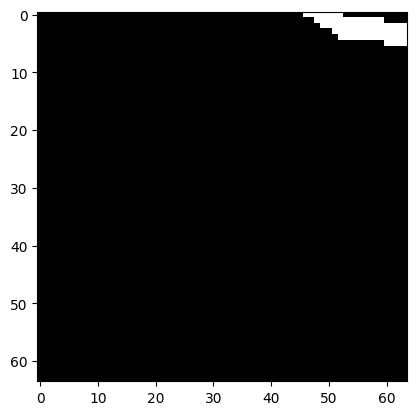

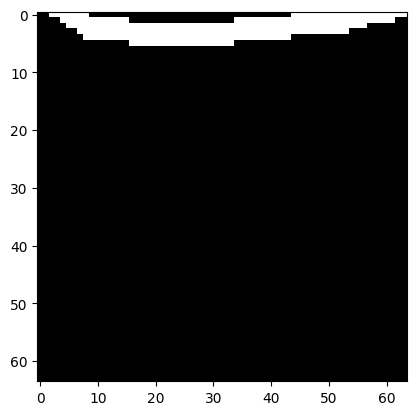

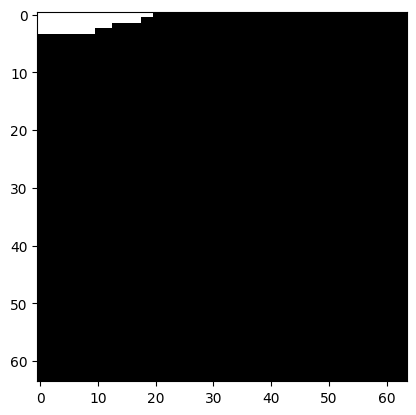

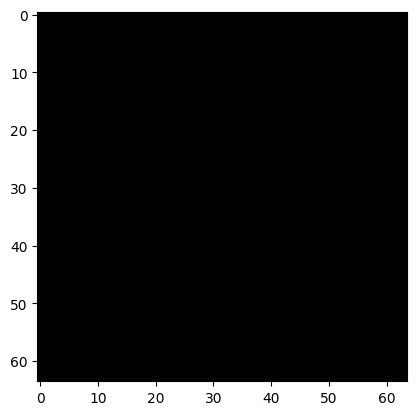

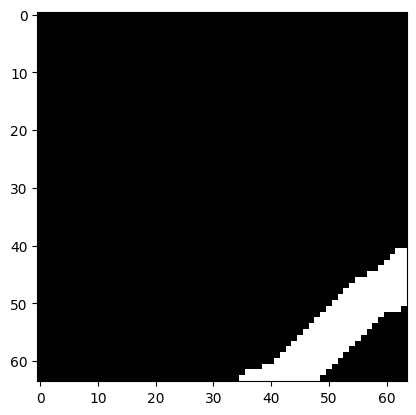

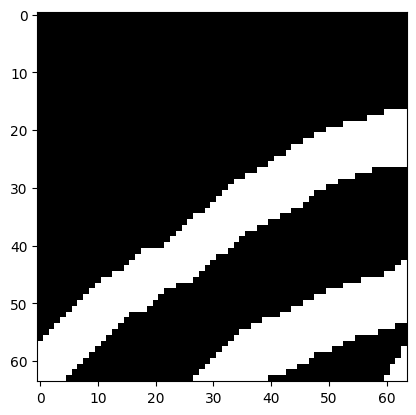

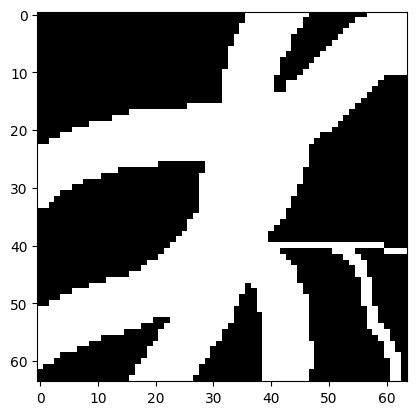

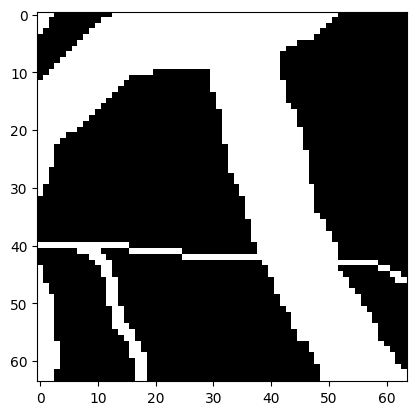

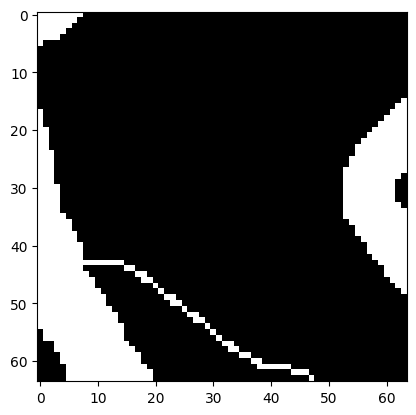

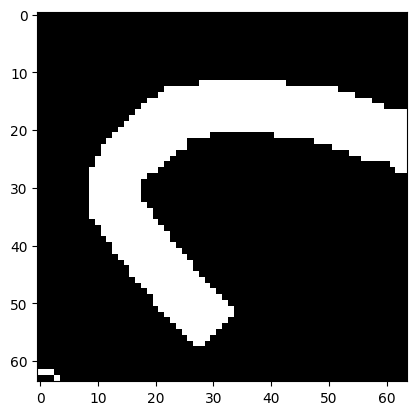

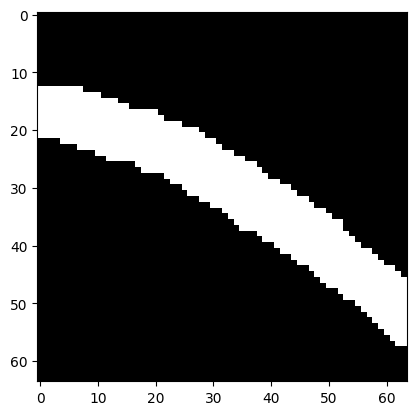

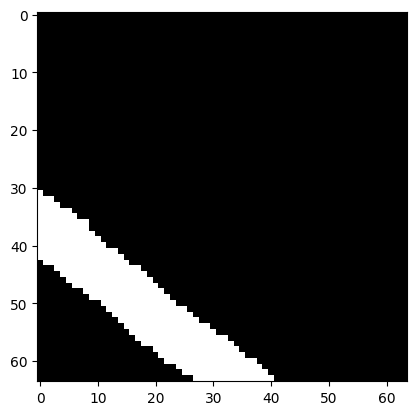

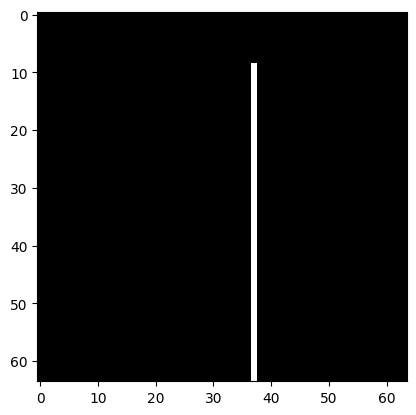

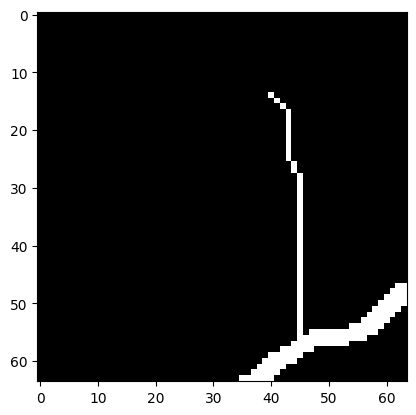

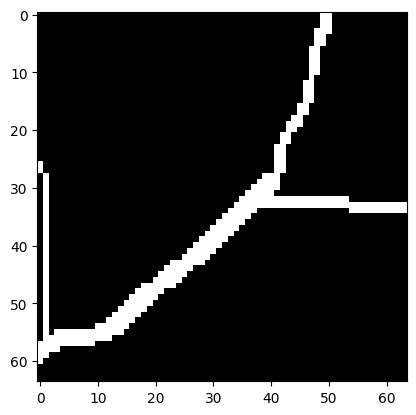

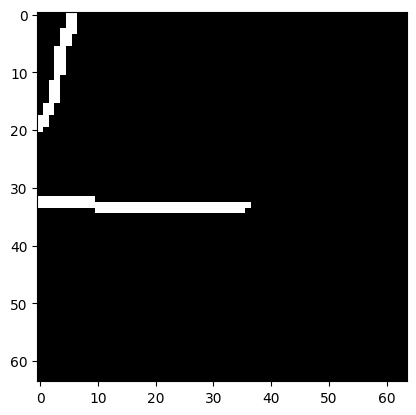

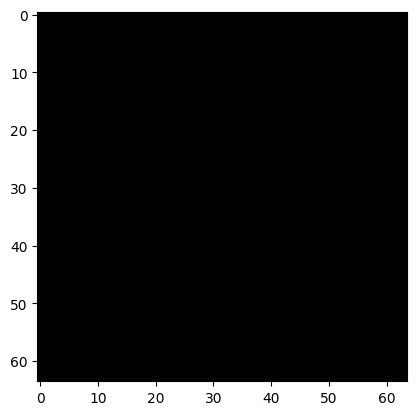

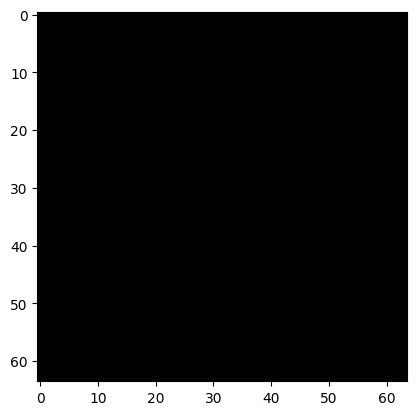

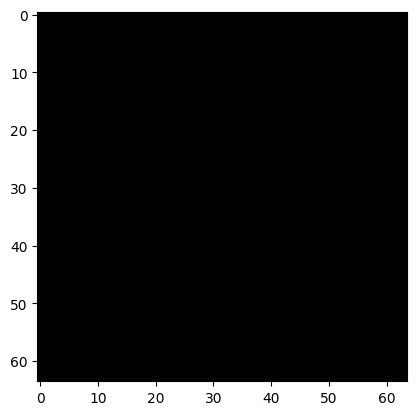

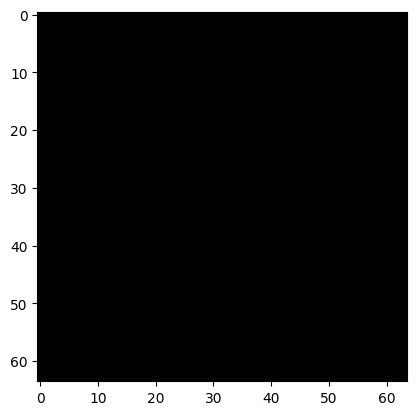

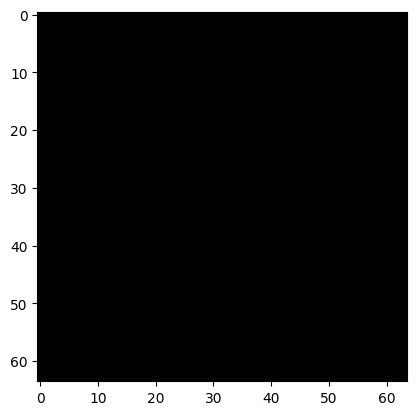

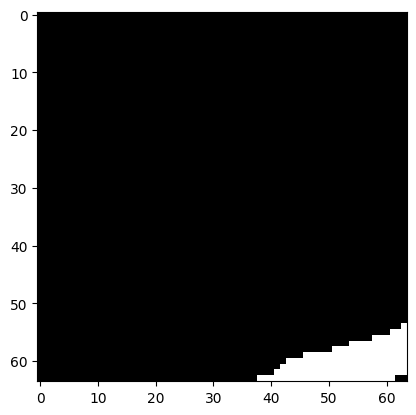

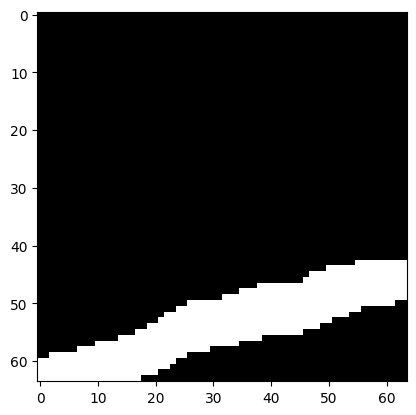

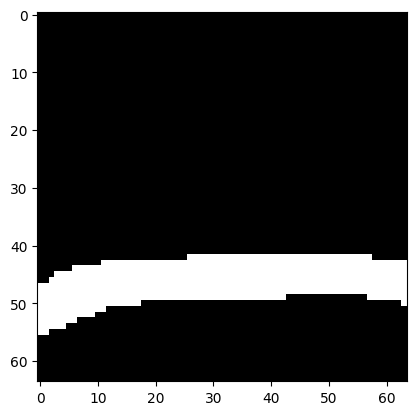

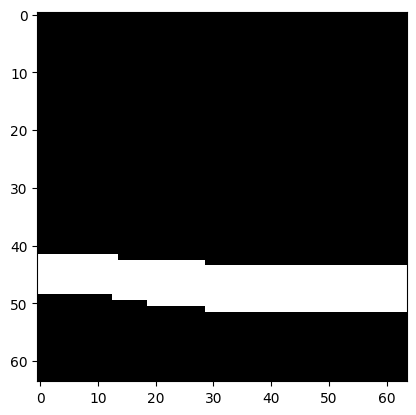

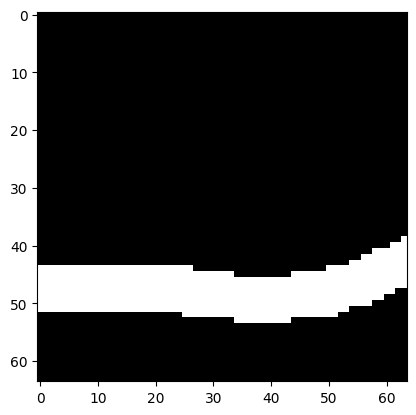

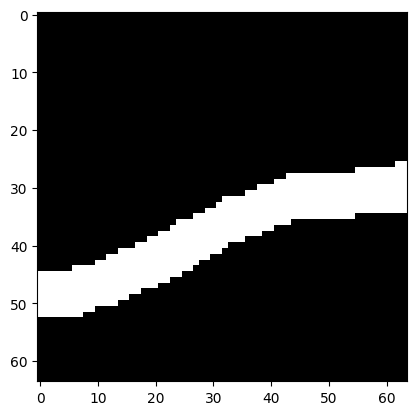

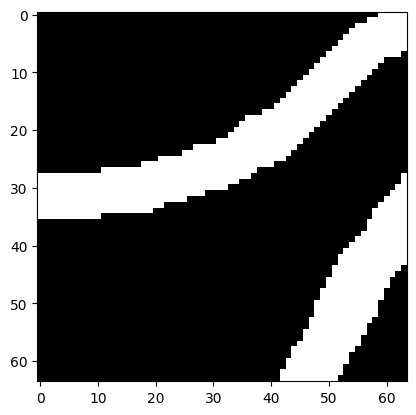

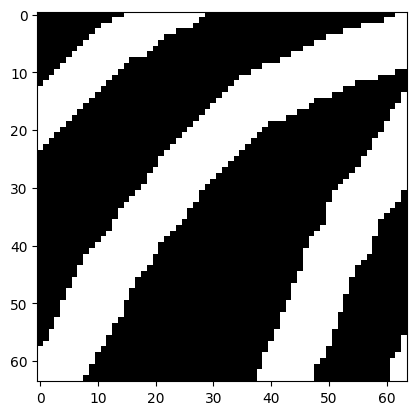

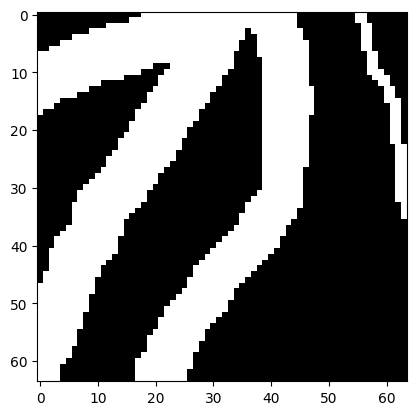

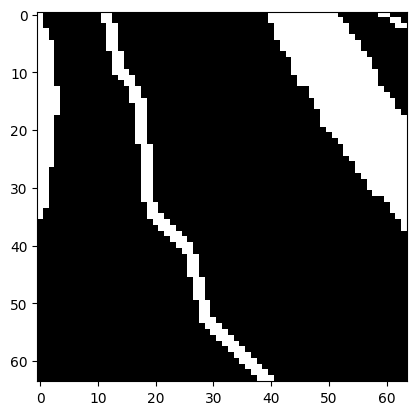

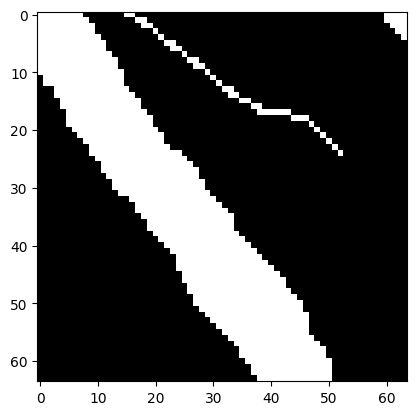

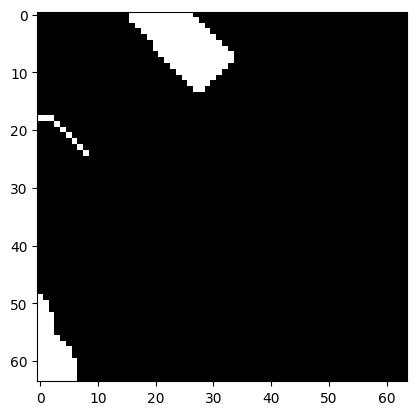

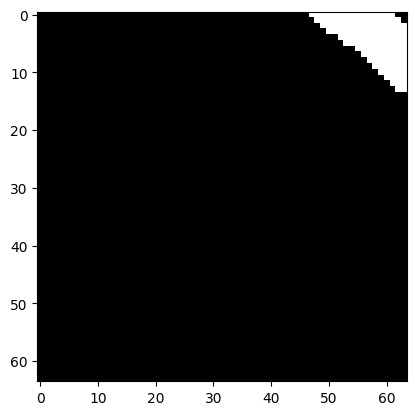

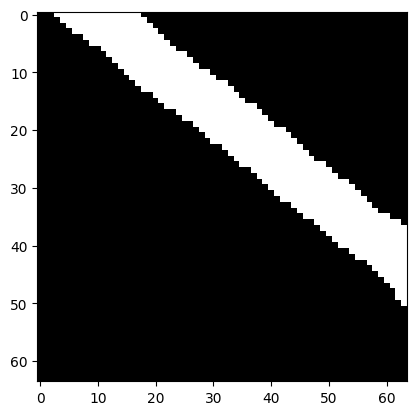

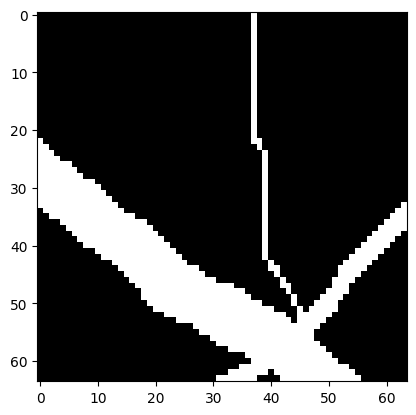

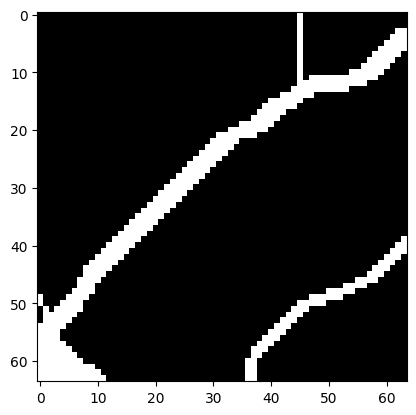

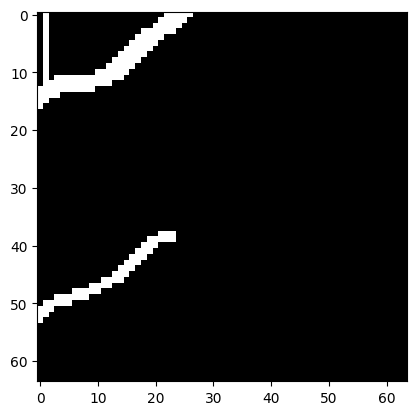

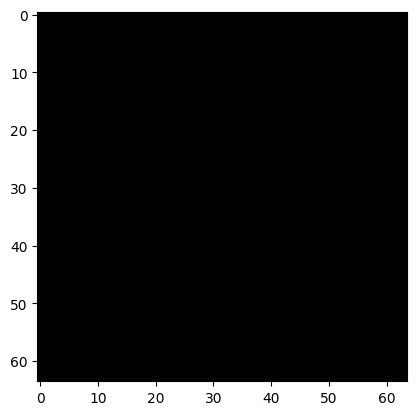

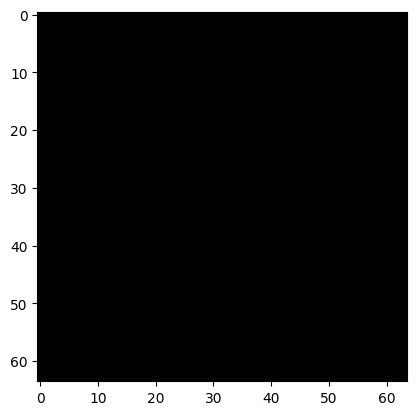

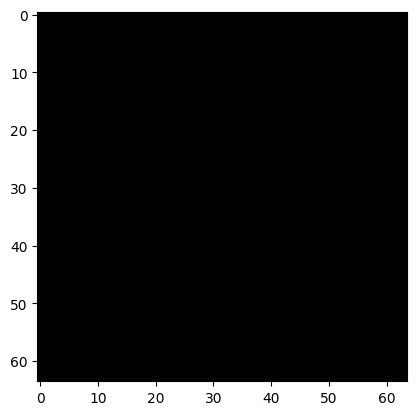

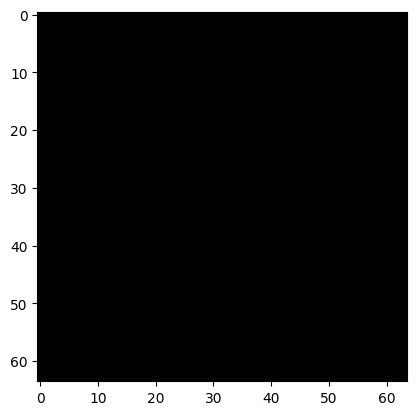

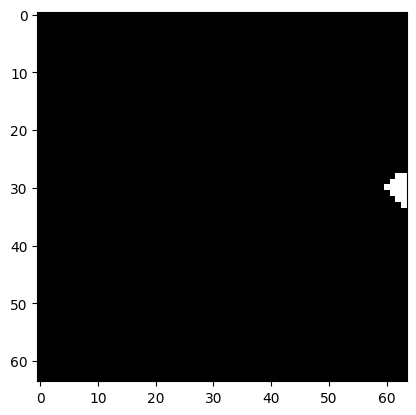

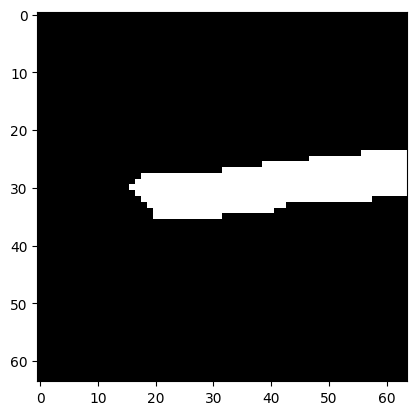

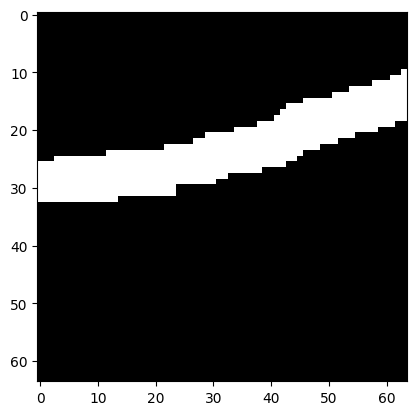

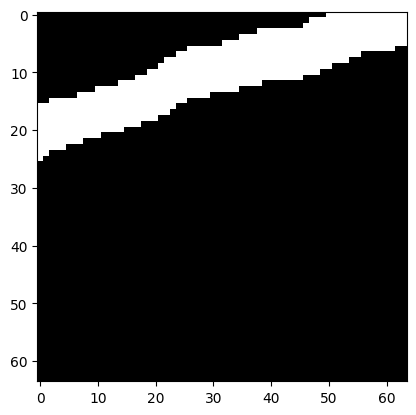

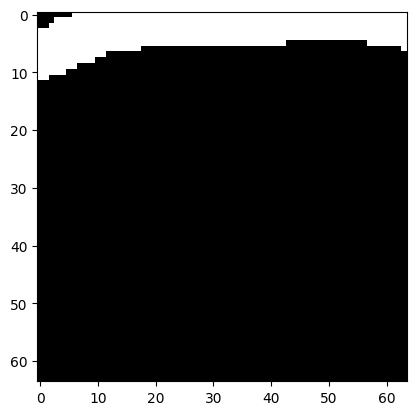

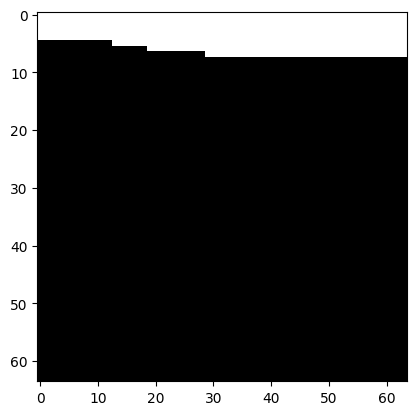

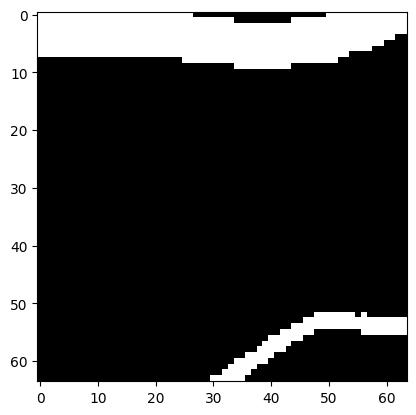

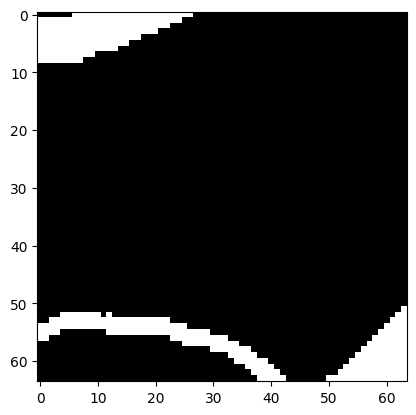

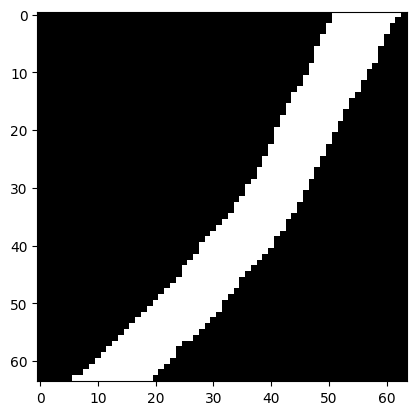

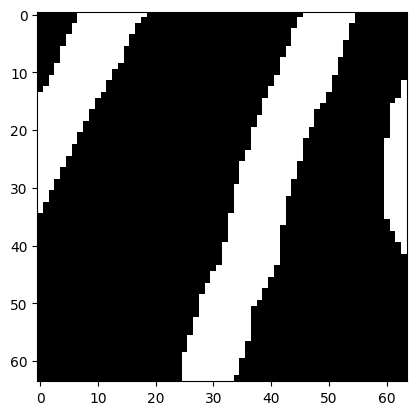

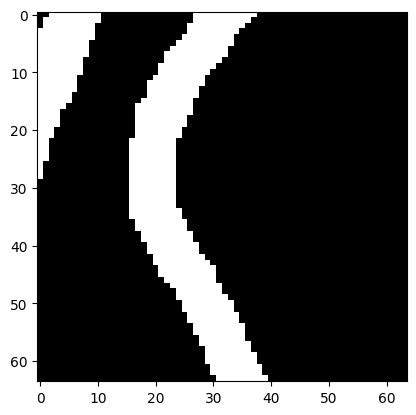

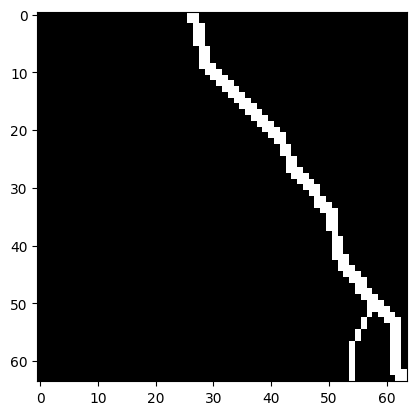

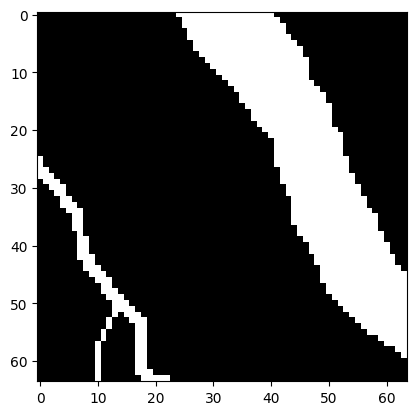

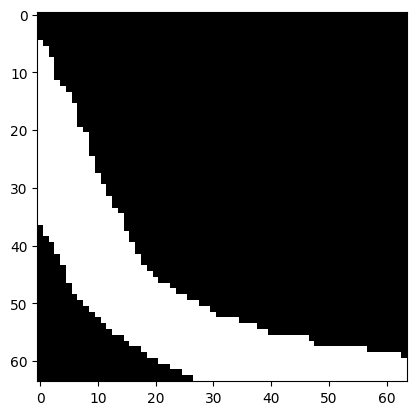

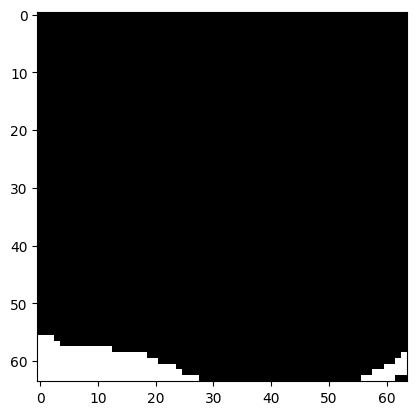

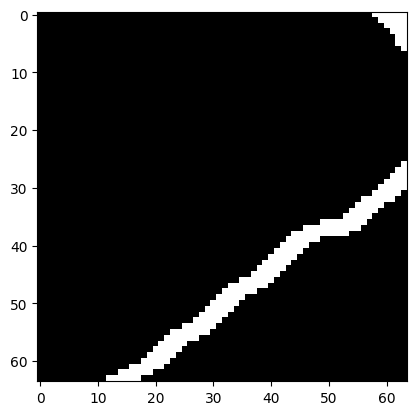

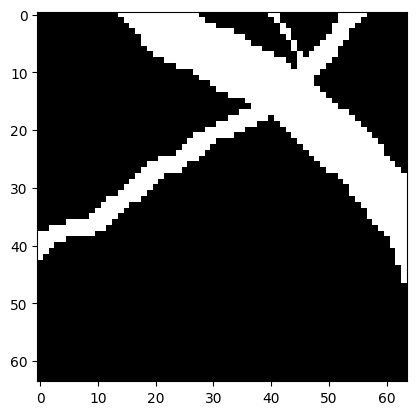

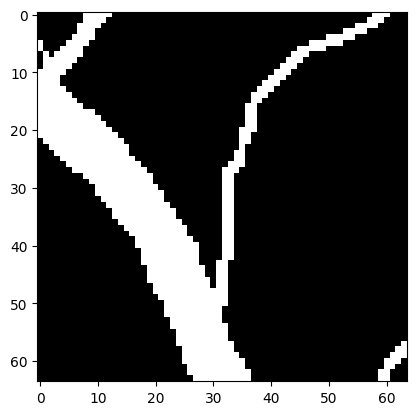

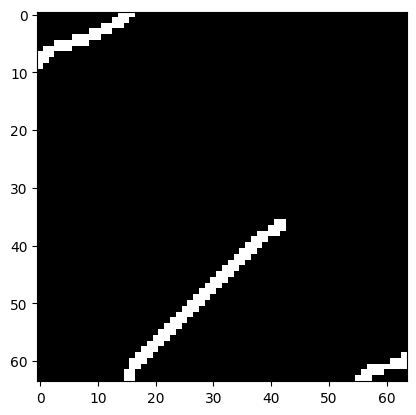

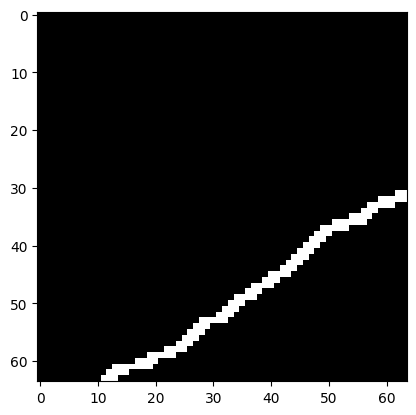

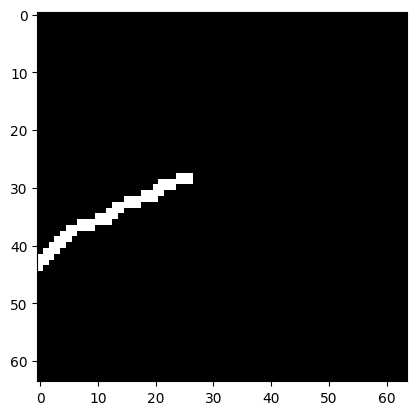

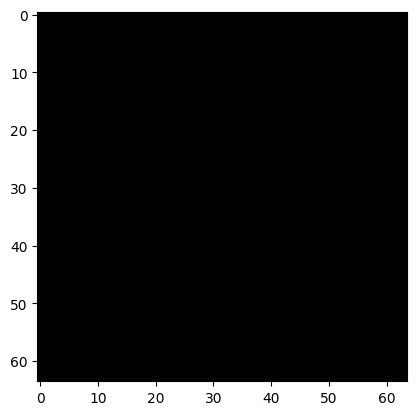

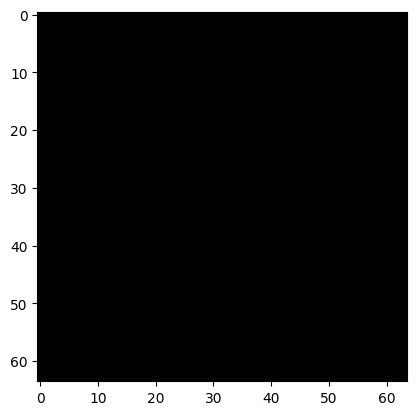

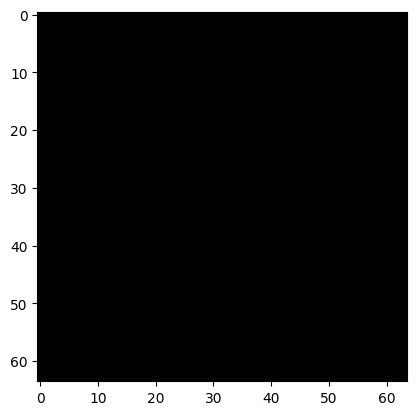

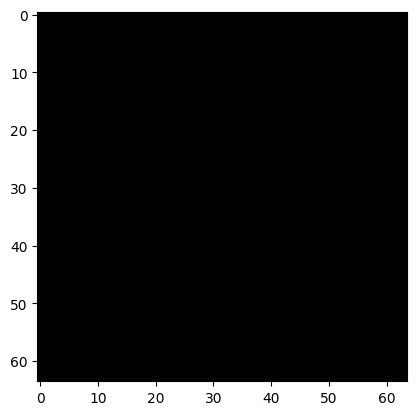

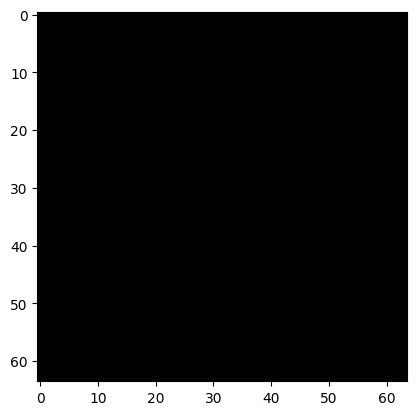

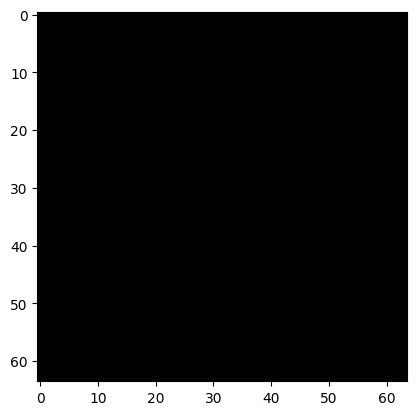

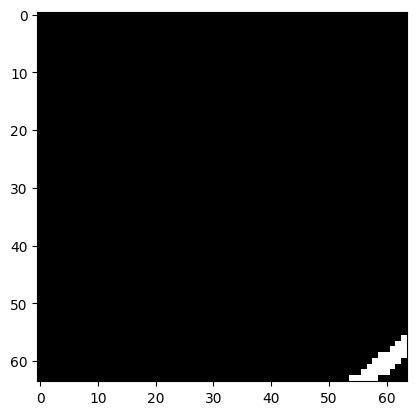

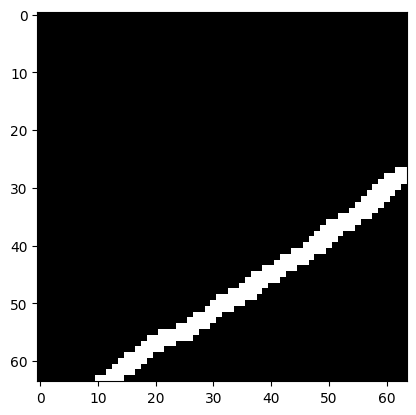

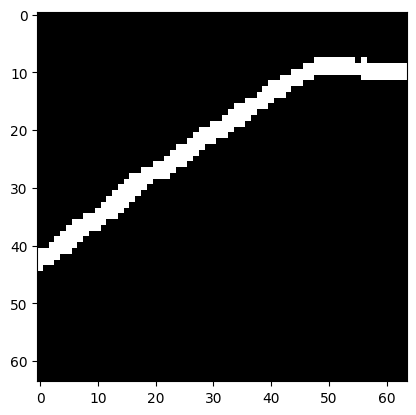

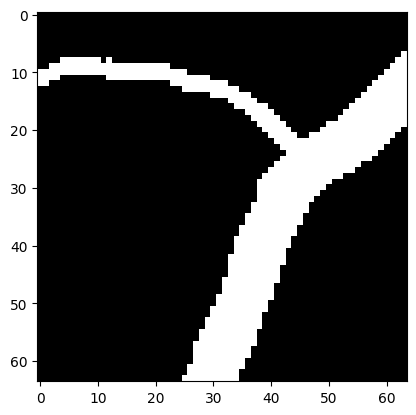

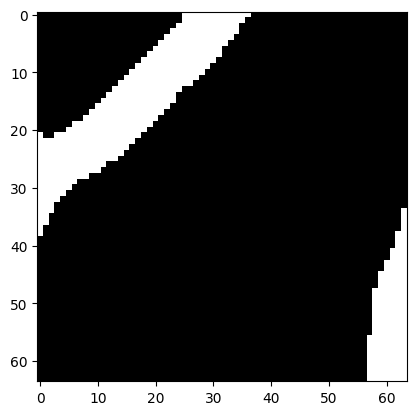

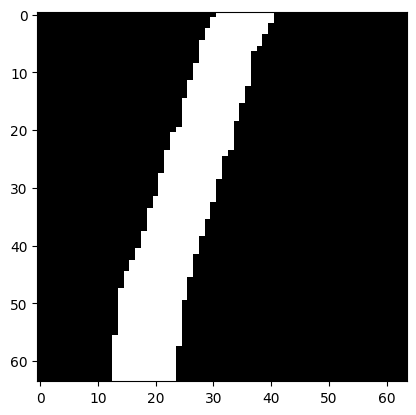

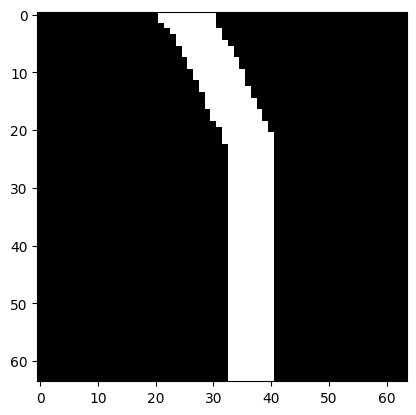

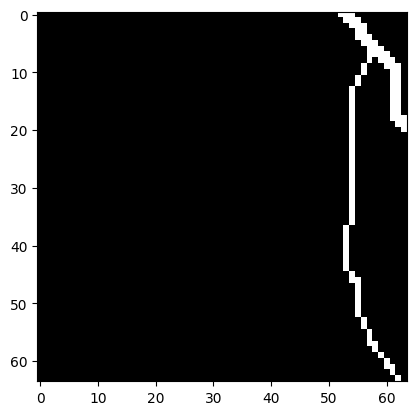

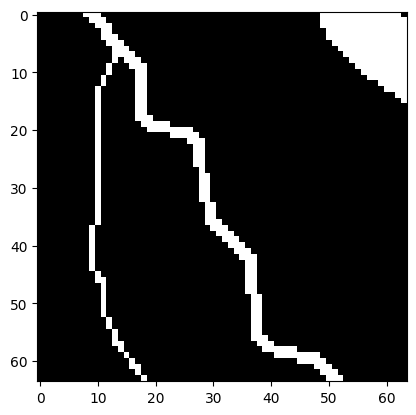

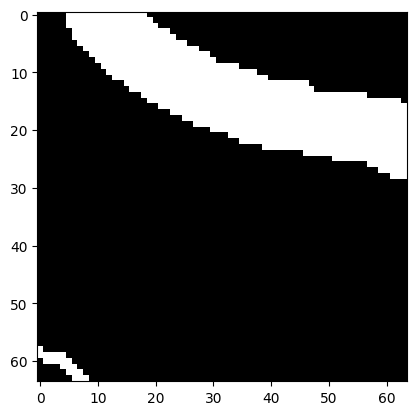

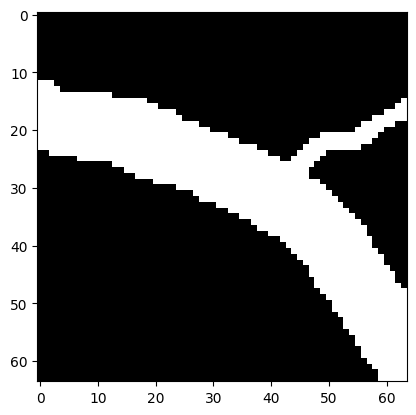

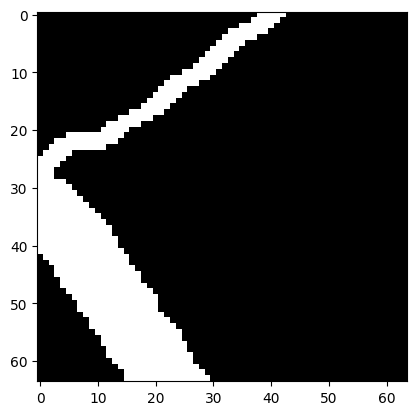

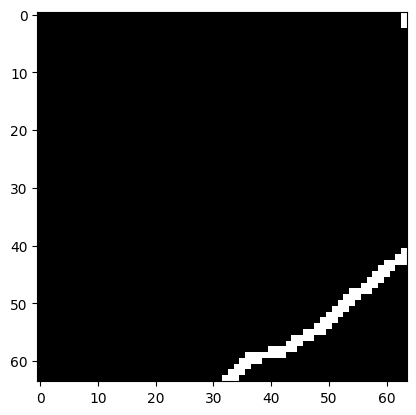

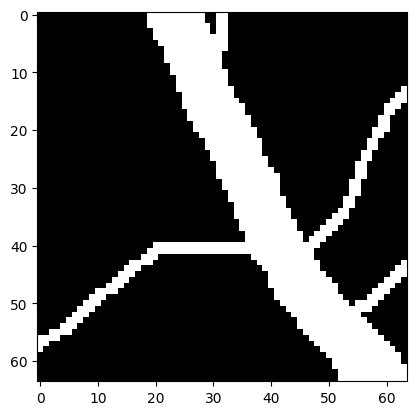

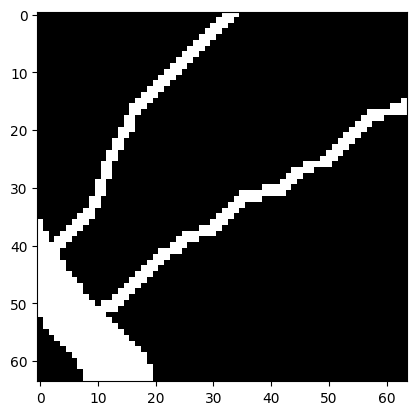

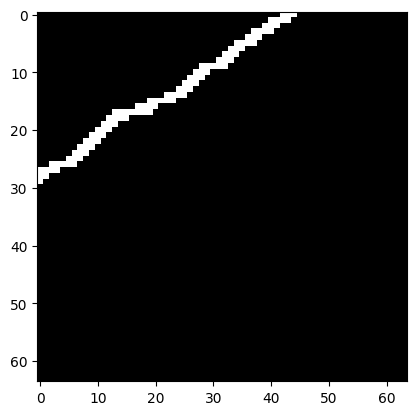

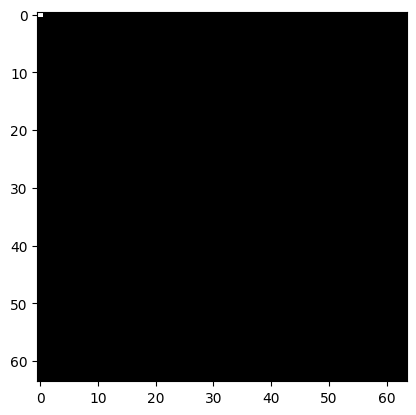

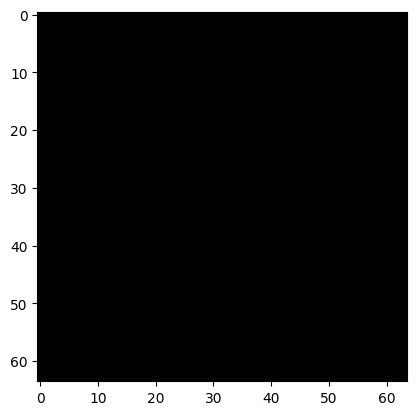

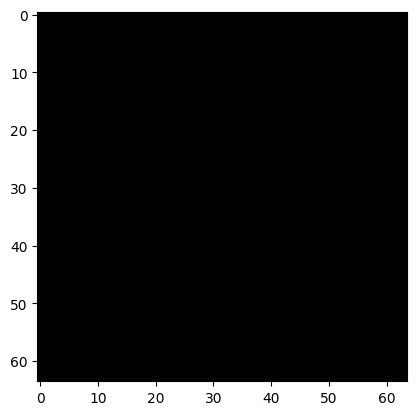

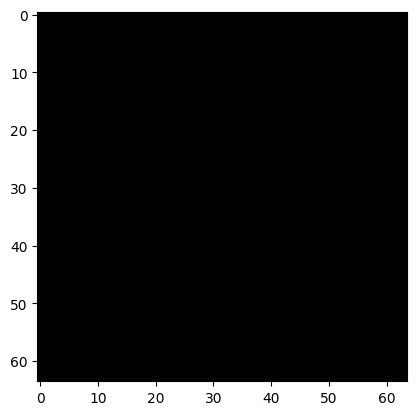

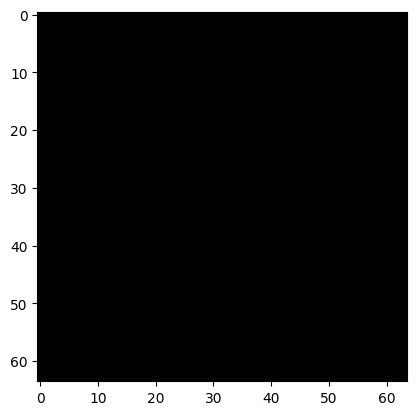

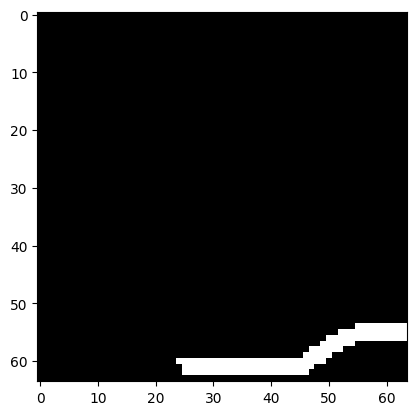

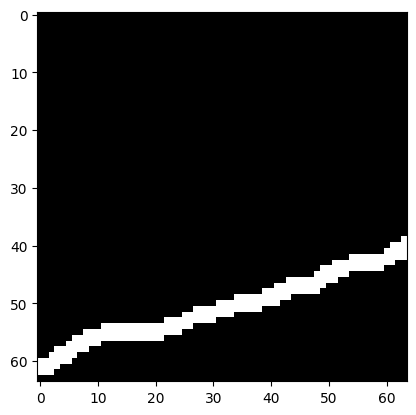

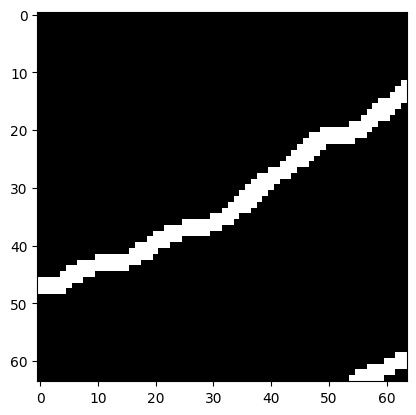

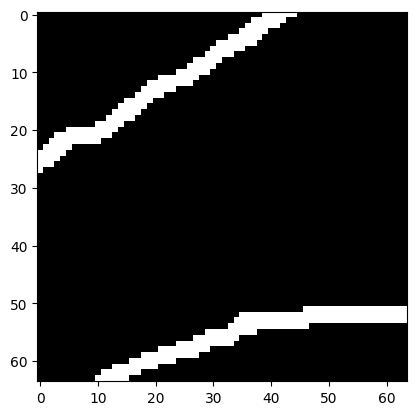

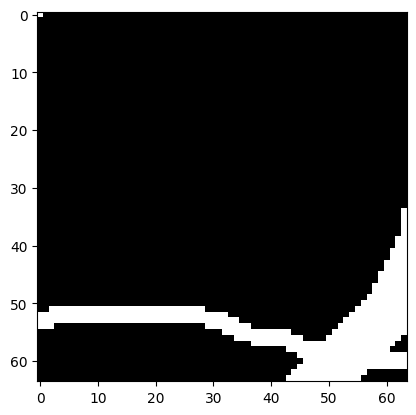

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [39]:
for p in patches.squeeze():
    plt.imshow(p,cmap='gray')
    plt.show()

In [21]:
cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/training/images/Image_01L.jpg',0).shape

(960, 999)

In [28]:
kornia.contrib.combine_tensor_patches(patches, original_size=(960, 999),window_size=64,stride=(44, 49),allow_auto_unpadding=True).squeeze().shape

torch.Size([960, 999])

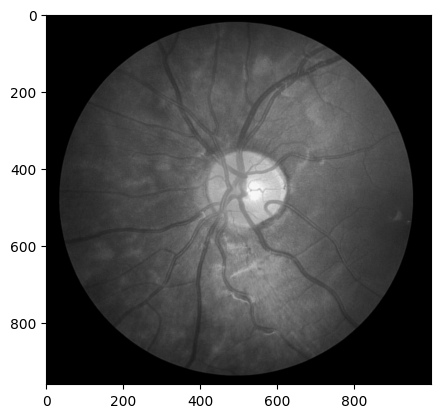

In [30]:
plt.imshow(cv2.imread('/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/training/images/Image_01L.jpg',0),cmap='gray')

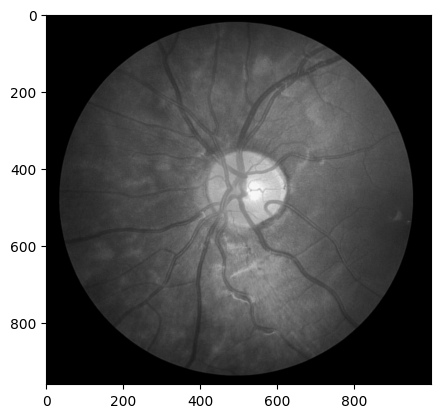

In [27]:
plt.imshow(kornia.contrib.combine_tensor_patches(patches, original_size=(960, 999),window_size=64,stride=(44, 49),allow_auto_unpadding=True).squeeze(),cmap='gray')

In [2]:
experts=nn.ModuleList([
    nn.Linear(4,8),
    nn.Linear(4,8),
    nn.Linear(4,8),
    nn.Linear(4,8),
])

In [ ]:
torch.load(experts.state_dict(),map_location='cpu')

AttributeError: 'collections.OrderedDict' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

In [16]:
router = nn.Linear(4,4)

In [56]:
import torch
from soft_moe_pytorch import SoftMoE

# sequence length or number of slots need not be specified

moe = SoftMoE(
    dim = 512,         # model dimensions
    num_experts = 4,   # number of experts
    num_slots=2
)

x = torch.randn(3, 1023, 512)

out = moe(x) + x # (1, 1023, 512)

In [57]:
out

tensor([[[-0.9663,  0.0497,  1.1916,  ..., -0.5923, -0.8868,  0.9819],
         [ 0.6256,  2.1203,  0.4602,  ...,  1.7533, -1.0952,  1.6947],
         [ 1.6321, -0.7464,  0.3624,  ...,  0.9660,  0.1386, -0.1409],
         ...,
         [ 0.8337, -0.4449,  0.4215,  ...,  0.6435,  0.0072, -0.2066],
         [-0.9057,  1.1523,  0.6554,  ..., -1.2107,  0.0201,  0.0317],
         [ 0.3108,  0.5757,  0.4073,  ..., -0.3106, -0.3347, -1.2551]],

        [[ 0.4000,  0.4616, -0.5011,  ...,  1.5084, -0.6855, -0.2586],
         [-0.3314,  0.2662, -1.0329,  ..., -1.2858, -0.4509,  0.9738],
         [-0.1888,  0.8991, -2.1566,  ...,  0.0584, -0.0944,  1.0026],
         ...,
         [ 1.6559,  3.0887,  0.9769,  ..., -1.3578,  1.0792, -0.5712],
         [ 0.2703, -1.4233, -1.1462,  ...,  1.9448,  0.2962,  1.4145],
         [ 1.2019,  0.3488,  0.9903,  ..., -0.9867, -0.2492, -0.3498]],

        [[-0.6232, -0.3320,  0.3172,  ...,  0.3101,  0.9198,  2.2486],
         [-1.3614,  1.3900,  0.5456,  ...,  1

In [17]:
x=torch.rand(3,3,4)

In [18]:
router_prob= router(x)

In [19]:
router_prob

tensor([[[ 0.0951,  0.2828, -0.1241, -0.1091],
         [-0.1858,  0.2263, -0.1948, -0.0479],
         [-0.1808,  0.3582, -0.4029, -0.0471]],

        [[-0.3417,  0.3016, -0.4791, -0.0723],
         [-0.1244,  0.3227, -0.3350, -0.1737],
         [-0.1172,  0.2011, -0.1581, -0.1050]],

        [[-0.0882,  0.3914, -0.2230,  0.0541],
         [ 0.1219,  0.1038,  0.0778, -0.0690],
         [-0.1803,  0.1575, -0.2333, -0.1731]]], grad_fn=<ViewBackward0>)

In [42]:
(router_prob.topk(2,-1).indices==1)

tensor([[[ True, False],
         [ True, False],
         [ True, False]],

        [[ True, False],
         [ True, False],
         [ True, False]],

        [[ True, False],
         [False,  True],
         [ True, False]]])

In [29]:
(router_prob.topk(2,-1).indices==0).any(-1)

tensor([[ True, False, False],
        [False,  True, False],
        [False,  True, False]])

In [47]:
x

tensor([[[0.3845, 0.8068, 0.9615, 0.0709],
         [0.1558, 0.3042, 0.0902, 0.4207],
         [0.5194, 0.5300, 0.9205, 0.8273]],

        [[0.5146, 0.1142, 0.6194, 0.9823],
         [0.0381, 0.1591, 0.8057, 0.1537],
         [0.1829, 0.2849, 0.2547, 0.1964]],

        [[0.0597, 0.8427, 0.4323, 0.5704],
         [0.7633, 0.9243, 0.4951, 0.1172],
         [0.3558, 0.0152, 0.3816, 0.2515]]])

In [ ]:
topk_experts= 

In [50]:
torch.exp(-torch.tensor(torch.inf))

tensor(0.)

In [ ]:

for i,expert in enumerate(experts):
    


In [4]:
import cv2 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [5]:
image_path = '/home/duypham/NCKH/Retinal-vessels-segmentation/data/CHASEDB_1/test/images/Image_11L.jpg'

In [3]:
img = np.array(Image.open(image_path).convert('RGB'))

In [4]:
r,g,b=img.transpose(2,0,1)

In [5]:
from scipy.signal import wiener,medfilt2d

In [6]:
def apply_gamma_correction(image, gamma=1.0):
    image_normalized = image / 255.0
    gamma_corrected = np.power(image_normalized, gamma)
    gamma_corrected = np.uint8(gamma_corrected * 255)

    return gamma_corrected

In [6]:
import sys
sys.path.append('/home/duypham/NCKH/Retinal-vessels-segmentation/')
from utils import *


In [47]:
from timm.models.maxxvit import window_partition,window_reverse

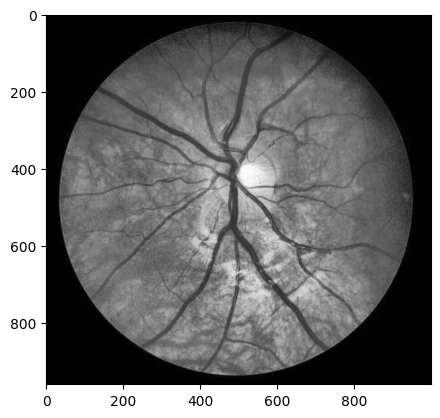

In [8]:
plt.imshow(preprocessing_img(image_path),cmap='gray')

In [48]:
img=preprocessing_img(image_path)

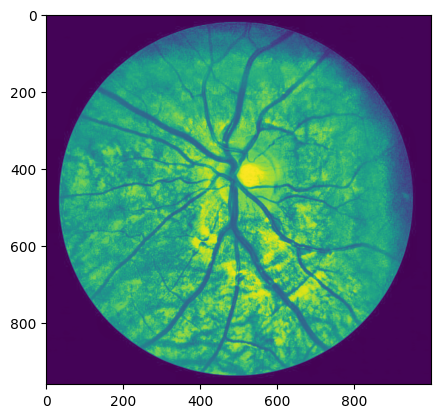

In [49]:
plt.imshow(img)

In [45]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
tf=A.Compose([
        A.Normalize(mean=(0.5,),std=(0.5,)),
        ToTensorV2()
    ])

In [70]:
x=torch.rand(2,1,1024,1024)

In [72]:
H,W=x.shape[-2:]

In [74]:
import kornia
patches = kornia.contrib.extract_tensor_patches(x, 64, 32)
patches[0,2,:,:,:]+=1
reconstructed = kornia.contrib.combine_tensor_patches(patches, original_size=(H,W),window_size=64,stride=32)

In [75]:
patches.shape

torch.Size([2, 961, 1, 64, 64])

In [ ]:
image = cv2.imread(self.images[index])
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2, tileGridSize=(8, 8))
cl = clahe.apply(l)

merged = cv2.merge((cl, a, b))
enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
gamma_corrected = adjust_gamma(enhanced, gamma=2)



image = self.transforms_img(image = np.mean(gamma_corrected,-1))['image']

mask = self.transforms_masks(image =(cv2.imread(self.masks[index],0)))['image'].squeeze()
return image,mask

In [88]:
15*15*4*4

3600

In [92]:
(1024-64)/16-1

59.0

In [ ]:
(1024-64)/s+1=10

In [93]:
reconstructed.shape

torch.Size([2, 1, 1024, 1024])

In [76]:
(x-reconstructed).sum()

tensor(-1536.)

In [52]:
window_partition(torch.rand(1,1024,768,3),[64,64],stride=1).shape

TypeError: window_partition() got an unexpected keyword argument 'stride'

In [42]:
window_reverse(window_partition(torch.rand(2,1024,768,3),[64,64]),(64,64),(1024,768)).shape

torch.Size([2, 1024, 768, 3])

In [ ]:
window_reverse(window_partition(mirror_padding_v2(tf(image=img)['image']).unsqueeze(0).permute(0,2,3,1).contiguous(),[64,64]),(64,64),[1024,1024]).permute(0,3,1,2).shape

torch.Size([1, 1, 1024, 1024])

In [ ]:
]window_partition(mirror_padding_v2(tf(image=img)['image']).unsqueeze(0).permute(0,2,3,1).contiguous(),[64,64]).permute(0,3,1,2).shape

torch.Size([256, 1, 64, 64])

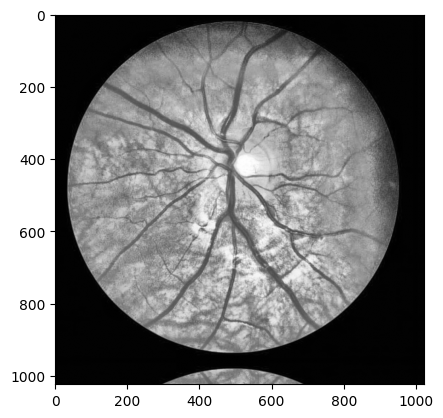

In [19]:
plt.imshow(mirror_padding_v2(tf(image=img)['image']).squeeze(),cmap='gray')

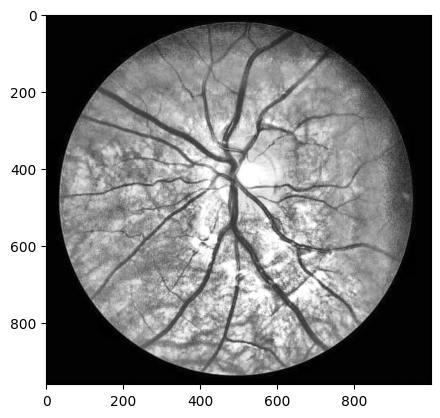

In [13]:
plt.imshow(convert_gray(gray_world(new_img)),cmap='gray')

In [14]:
wavelet_enhance(new_img,level=2, scale=1.3).shape

(960, 1000, 3)

In [15]:
img.shape

(960, 999)

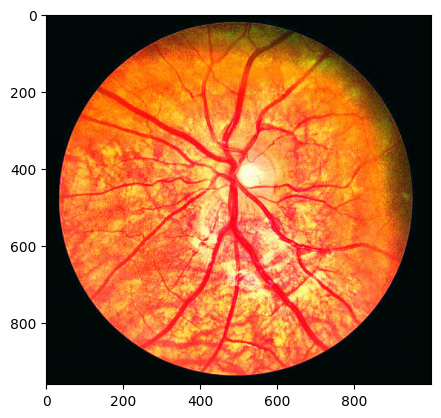

In [16]:
plt.imshow(wavelet_enhance(new_img,level=2, scale=1.3))

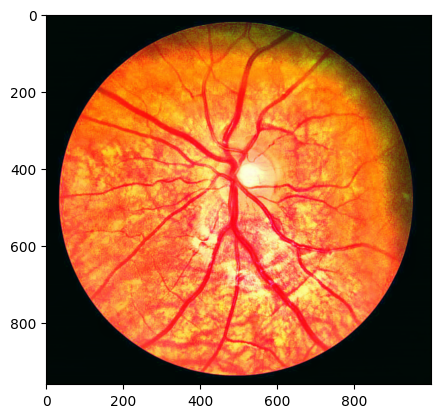

In [17]:
plt.imshow(homomorphic_filter(new_img,80))

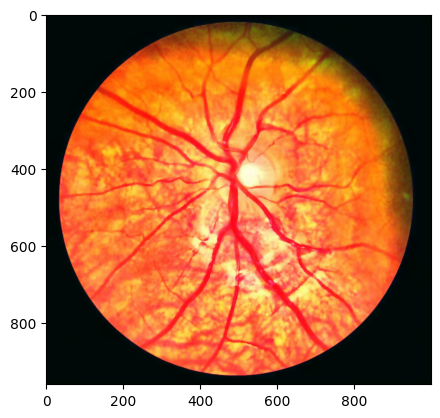

In [18]:
plt.imshow( cv2.bilateralFilter(new_img, d=9, sigmaColor=75, sigmaSpace=75))

In [19]:
unsharp_mask(new_img,amount=1.2).shape

(960, 999, 3)

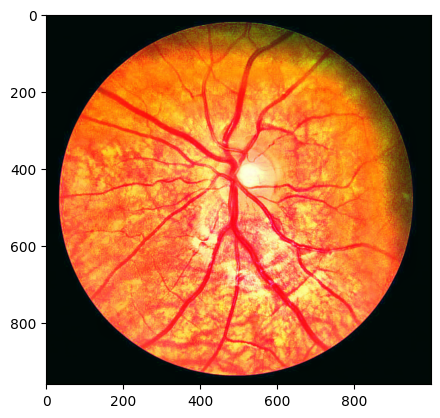

In [20]:
plt.imshow(unsharp_mask(new_img,amount=1.2))

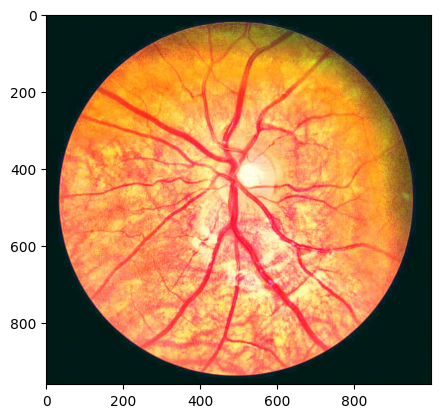

In [21]:
plt.imshow(gamma_correction(new_img,1.5))